# Dataset Loading and Inspection

In [1]:
import os

DATASET_PATH = r"D:\Projects\Client Projects\Implementation\3661\music_dataset"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset path not found: {DATASET_PATH}")

class_counts = {}

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        count = 0

        for root, _, files in os.walk(class_path):
            count += len(files)

        class_counts[class_name] = count

print("Dataset Loaded Successfully")
print("\nClass Distribution:")
print("-" * 40)

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("-" * 40)
print(f"Total Classes: {len(class_counts)}")
print(f"Total Files: {sum(class_counts.values())}")


Dataset Loaded Successfully

Class Distribution:
----------------------------------------
Bass: 3613
Drum_set: 3648
Guitar: 3654
Guitar_1: 500
Harmonica: 131
Harmonium: 1314
Piano: 575
Trumpet: 503
Violin: 630
flute: 3719
----------------------------------------
Total Classes: 10
Total Files: 18287


# Data Splitting into Training - 70%, Validation - 15% and Test - 15%

In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

SOURCE_DIR = r"D:\Projects\Client Projects\Implementation\3661\music_dataset"

OUTPUT_DIR = r"D:\Projects\Client Projects\Implementation\3661\music_dataset_split"

TRAIN_DIR = os.path.join(OUTPUT_DIR, "train")
VAL_DIR   = os.path.join(OUTPUT_DIR, "validation")
TEST_DIR  = os.path.join(OUTPUT_DIR, "test")

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

RANDOM_SEED = 42

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

classes = sorted([
    d for d in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, d))
])

print("Classes Found:")
for cls in classes:
    print(cls)

print("\n" + "=" * 70)

total_train = 0
total_val = 0
total_test = 0

for class_name in classes:

    class_source = os.path.join(SOURCE_DIR, class_name)

    files = [
        f for f in os.listdir(class_source)
        if os.path.isfile(os.path.join(class_source, f))
    ]

    train_files, temp_files = train_test_split(
        files,
        test_size=(VAL_RATIO + TEST_RATIO),
        random_state=RANDOM_SEED,
        shuffle=True
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=RANDOM_SEED,
        shuffle=True
    )

    train_class_dir = os.path.join(TRAIN_DIR, class_name)
    val_class_dir   = os.path.join(VAL_DIR, class_name)
    test_class_dir  = os.path.join(TEST_DIR, class_name)

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    for file_name in train_files:

        src = os.path.join(class_source, file_name)
        dst = os.path.join(train_class_dir, file_name)

        shutil.copy2(src, dst)

    for file_name in val_files:

        src = os.path.join(class_source, file_name)
        dst = os.path.join(val_class_dir, file_name)

        shutil.copy2(src, dst)

    for file_name in test_files:

        src = os.path.join(class_source, file_name)
        dst = os.path.join(test_class_dir, file_name)

        shutil.copy2(src, dst)

    total_train += len(train_files)
    total_val += len(val_files)
    total_test += len(test_files)

    print(
        f"{class_name:<12} | "
        f"Total: {len(files):>5} | "
        f"Train: {len(train_files):>5} | "
        f"Validation: {len(val_files):>5} | "
        f"Test: {len(test_files):>5}"
    )

total_files = total_train + total_val + total_test

print("\n" + "=" * 70)
print("Original Audio File Split Completed Successfully")
print("=" * 70)

print(f"Total Original Files : {total_files}")
print(f"Training Files       : {total_train}")
print(f"Validation Files     : {total_val}")
print(f"Testing Files        : {total_test}")

print("\nSplit Ratio:")
print(f"Training   : {total_train / total_files * 100:.2f}%")
print(f"Validation : {total_val / total_files * 100:.2f}%")
print(f"Testing    : {total_test / total_files * 100:.2f}%")

Classes Found:
Bass
Drum_set
Guitar
Guitar_1
Harmonica
Harmonium
Piano
Trumpet
Violin
flute

Bass         | Total:  3613 | Train:  2529 | Validation:   542 | Test:   542
Drum_set     | Total:  3648 | Train:  2553 | Validation:   547 | Test:   548
Guitar       | Total:  3654 | Train:  2557 | Validation:   548 | Test:   549
Guitar_1     | Total:   500 | Train:   350 | Validation:    75 | Test:    75
Harmonica    | Total:   131 | Train:    91 | Validation:    20 | Test:    20
Harmonium    | Total:  1314 | Train:   919 | Validation:   197 | Test:   198
Piano        | Total:   575 | Train:   402 | Validation:    86 | Test:    87
Trumpet      | Total:   503 | Train:   352 | Validation:    75 | Test:    76
Violin       | Total:   630 | Train:   441 | Validation:    94 | Test:    95
flute        | Total:  3719 | Train:  2603 | Validation:   558 | Test:   558

Original Audio File Split Completed Successfully
Total Original Files : 18287
Training Files       : 12797
Validation Files     : 2742
T

# Preprocessing - Pitch Normalization, Band-Pass Filtering and Audio Segmentation

In [3]:
import os
import warnings
import numpy as np
import librosa
import soundfile as sf

from scipy.signal import butter, sosfilt

warnings.filterwarnings("ignore")

INPUT_DIR = r"D:\Projects\Client Projects\Implementation\3661\music_dataset_split"

OUTPUT_DIR = r"D:\Projects\Client Projects\Implementation\3661\music_dataset_preprocessed"

TARGET_SR = 44100

FMIN = 80.0
FMAX = 1000.0

REFERENCE_PITCH = 440.0

FILTER_ORDER = 4
LOWER_CUTOFF = 80.0
UPPER_CUTOFF = 12000.0

SEGMENT_DURATION = 3.0
OVERLAP_RATIO = 0.50

SEGMENT_SAMPLES = int(TARGET_SR * SEGMENT_DURATION)

HOP_SAMPLES = int(
    SEGMENT_SAMPLES * (1.0 - OVERLAP_RATIO)
)

for split in ["train", "validation", "test"]:

    split_path = os.path.join(OUTPUT_DIR, split)

    os.makedirs(split_path, exist_ok=True)

# BAND-PASS FILTER

def bandpass_filter(
    audio,
    sample_rate,
    low_cutoff=80.0,
    high_cutoff=12000.0,
    order=4
):

    nyquist = sample_rate / 2.0

    if high_cutoff >= nyquist:
        high_cutoff = nyquist - 100.0

    low = low_cutoff / nyquist
    high = high_cutoff / nyquist

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        output="sos"
    )

    filtered_audio = sosfilt(
        sos,
        audio
    )

    return filtered_audio


# pYIN F0 ESTIMATION

def estimate_f0(audio, sample_rate):

    try:

        f0, voiced_flag, voiced_prob = librosa.pyin(
            audio,
            fmin=FMIN,
            fmax=FMAX,
            sr=sample_rate,
            frame_length=2048,
            hop_length=512
        )

        valid_f0 = f0[
            np.isfinite(f0) &
            (f0 >= FMIN) &
            (f0 <= FMAX)
        ]

        if len(valid_f0) == 0:
            return None

        median_f0 = float(
            np.median(valid_f0)
        )

        return median_f0

    except Exception:

        return None

def calculate_semitone_shift(
    estimated_f0,
    reference_pitch=440.0
):

    if estimated_f0 is None:
        return 0.0

    if estimated_f0 <= 0:
        return 0.0

    semitone_shift = (
        12.0 *
        np.log2(reference_pitch / estimated_f0)
    )

    return float(semitone_shift)

def pitch_normalize(
    audio,
    sample_rate,
    estimated_f0
):

    if estimated_f0 is None:

        return audio, 0.0

    semitone_shift = calculate_semitone_shift(
        estimated_f0,
        REFERENCE_PITCH
    )

    if abs(semitone_shift) < 0.01:

        return audio, semitone_shift

    try:

        normalized_audio = librosa.effects.pitch_shift(
            audio,
            sr=sample_rate,
            n_steps=semitone_shift,
            bins_per_octave=12,
            res_type="soxr_hq"
        )

        return normalized_audio, semitone_shift

    except Exception as e:

        print(
            f"Pitch normalization failed: {e}"
        )

        return audio, 0.0

# AUDIO SEGMENTATION

def create_segments(
    audio,
    segment_samples,
    hop_samples
):

    segments = []

    audio_length = len(audio)

    start = 0

    while start < audio_length:

        end = start + segment_samples

        segment = audio[start:end]

        if len(segment) < segment_samples:

            padding_length = (
                segment_samples -
                len(segment)
            )

            segment = np.pad(
                segment,
                (0, padding_length),
                mode="constant"
            )

        segments.append(segment)

        if end >= audio_length:
            break

        start += hop_samples

    return segments

def process_audio_file(
    input_file,
    output_class_dir,
    file_index
):

    try:

        audio, sr = librosa.load(
            input_file,
            sr=TARGET_SR,
            mono=True
        )

        if audio is None or len(audio) == 0:

            print(
                f"Skipping empty file: "
                f"{os.path.basename(input_file)}"
            )

            return 0

        max_value = np.max(
            np.abs(audio)
        )

        if max_value > 0:

            audio = (
                audio /
                max_value
            )

        estimated_f0 = estimate_f0(
            audio,
            TARGET_SR
        )

        semitone_shift = calculate_semitone_shift(
            estimated_f0,
            REFERENCE_PITCH
        )

        audio, applied_shift = pitch_normalize(
            audio,
            TARGET_SR,
            estimated_f0
        )

        audio = bandpass_filter(
            audio,
            TARGET_SR,
            low_cutoff=LOWER_CUTOFF,
            high_cutoff=UPPER_CUTOFF,
            order=FILTER_ORDER
        )

        segments = create_segments(
            audio,
            SEGMENT_SAMPLES,
            HOP_SAMPLES
        )

        base_name = os.path.splitext(
            os.path.basename(input_file)
        )[0]

        saved_count = 0

        for segment_number, segment in enumerate(
            segments,
            start=1
        ):

            output_filename = (
                f"{base_name}_"
                f"segment_{segment_number:04d}.wav"
            )

            output_file = os.path.join(
                output_class_dir,
                output_filename
            )

            # Final amplitude normalization
            max_segment = np.max(
                np.abs(segment)
            )

            if max_segment > 0:

                segment = (
                    segment /
                    max_segment
                )

            sf.write(
                output_file,
                segment,
                TARGET_SR,
                subtype="PCM_16"
            )

            saved_count += 1

        return saved_count

    except Exception as e:

        print(
            f"Error processing "
            f"{os.path.basename(input_file)}: {e}"
        )

        return 0

total_files = 0
total_segments = 0


for split in ["train", "validation", "test"]:

    split_input_dir = os.path.join(
        INPUT_DIR,
        split
    )

    split_output_dir = os.path.join(
        OUTPUT_DIR,
        split
    )

    print("\n")
    print("=" * 70)
    print(f"PROCESSING: {split.upper()}")
    print("=" * 70)

    classes = sorted([
        d for d in os.listdir(split_input_dir)
        if os.path.isdir(
            os.path.join(
                split_input_dir,
                d
            )
        )
    ])

    for class_name in classes:

        input_class_dir = os.path.join(
            split_input_dir,
            class_name
        )

        output_class_dir = os.path.join(
            split_output_dir,
            class_name
        )

        os.makedirs(
            output_class_dir,
            exist_ok=True
        )

        audio_files = sorted([
            f for f in os.listdir(
                input_class_dir
            )
            if f.lower().endswith(
                (
                    ".wav",
                    ".mp3",
                    ".flac",
                    ".ogg",
                    ".m4a",
                    ".aac"
                )
            )
        ])

        print(
            f"\nClass: {class_name}"
        )

        print(
            f"Original files: "
            f"{len(audio_files)}"
        )

        class_segments = 0

        for index, file_name in enumerate(
            audio_files,
            start=1
        ):

            input_file = os.path.join(
                input_class_dir,
                file_name
            )

            segments_saved = process_audio_file(
                input_file,
                output_class_dir,
                index
            )

            class_segments += segments_saved
            total_files += 1

            # Progress
            if index % 50 == 0 or index == len(audio_files):

                print(
                    f"Processed "
                    f"{index}/{len(audio_files)} | "
                    f"Segments: {class_segments}"
                )

        total_segments += class_segments

        print(
            f"Class completed: {class_name}"
        )

        print(
            f"Final segments: {class_segments}"
        )

print("\n")
print("=" * 70)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"Original audio files processed: "
    f"{total_files}"
)

print(
    f"Total 3-second segments saved: "
    f"{total_segments}"
)

print(
    f"Sampling rate: "
    f"{TARGET_SR} Hz"
)

print(
    f"pYIN F0 range: "
    f"{FMIN}–{FMAX} Hz"
)

print(
    f"Reference pitch: "
    f"{REFERENCE_PITCH} Hz"
)

print(
    f"Band-pass filter: "
    f"{LOWER_CUTOFF}–{UPPER_CUTOFF} Hz"
)

print(
    f"Filter order: "
    f"{FILTER_ORDER}"
)

print(
    f"Segment duration: "
    f"{SEGMENT_DURATION} seconds"
)

print(
    f"Overlap: "
    f"{OVERLAP_RATIO * 100:.0f}%"
)

print("=" * 70)


PROCESSING: TRAIN

Class: Bass
Original files: 2529
Processed 50/2529 | Segments: 50
Processed 100/2529 | Segments: 100
Processed 150/2529 | Segments: 150
Processed 200/2529 | Segments: 200
Processed 250/2529 | Segments: 250
Processed 300/2529 | Segments: 300
Processed 350/2529 | Segments: 350
Processed 400/2529 | Segments: 400
Processed 450/2529 | Segments: 450
Processed 500/2529 | Segments: 500
Processed 550/2529 | Segments: 550
Processed 600/2529 | Segments: 600
Processed 650/2529 | Segments: 650
Processed 700/2529 | Segments: 700
Processed 750/2529 | Segments: 750
Processed 800/2529 | Segments: 800
Processed 850/2529 | Segments: 850
Processed 900/2529 | Segments: 900
Processed 950/2529 | Segments: 950
Processed 1000/2529 | Segments: 1000
Processed 1050/2529 | Segments: 1050
Processed 1100/2529 | Segments: 1100
Processed 1150/2529 | Segments: 1150
Processed 1200/2529 | Segments: 1200
Processed 1250/2529 | Segments: 1250
Processed 1300/2529 | Segments: 1300
Processed 1350/2529 | Seg

# Feature Extraction - Mel-Frequency Cepstral Coefficients (MFCC)

In [4]:
import os
import random
import numpy as np
import pandas as pd
import librosa

from itertools import combinations

INPUT_DIR = (
    r"D:\Projects\Client Projects\Implementation\3661"
    r"\music_dataset_preprocessed"
)

OUTPUT_DIR = (
    r"D:\Projects\Client Projects\Implementation\3661"
    r"\music_mfcc_pairs"
)

FEATURE_DIR = os.path.join(
    OUTPUT_DIR,
    "mfcc_features"
)

PAIR_DIR = os.path.join(
    OUTPUT_DIR,
    "pair_csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FEATURE_DIR,
    exist_ok=True
)

os.makedirs(
    PAIR_DIR,
    exist_ok=True
)

N_MFCC = 40

N_FFT = 2048

FRAME_LENGTH_MS = 25

HOP_LENGTH_MS = 10

N_MELS = 128

WINDOW = "hann"

RANDOM_SEED = 42

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)

AUDIO_EXTENSIONS = (
    ".wav",
    ".mp3",
    ".flac",
    ".ogg",
    ".m4a",
    ".aac"
)


def get_audio_files(split_dir):

    class_files = {}

    if not os.path.exists(split_dir):

        raise FileNotFoundError(
            f"Split directory not found:\n"
            f"{split_dir}"
        )

    classes = sorted([
        d
        for d in os.listdir(split_dir)
        if os.path.isdir(
            os.path.join(
                split_dir,
                d
            )
        )
    ])

    for class_name in classes:

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        files = sorted([
            os.path.join(
                class_dir,
                f
            )
            for f in os.listdir(class_dir)
            if f.lower().endswith(
                AUDIO_EXTENSIONS
            )
            and os.path.isfile(
                os.path.join(
                    class_dir,
                    f
                )
            )
        ])

        class_files[class_name] = files

    return class_files

def print_dataset_information(
    split,
    class_files
):

    print("\n")
    print("=" * 70)
    print(
        f"DATASET INFORMATION: "
        f"{split.upper()}"
    )
    print("=" * 70)

    total_files = 0

    for class_name, files in class_files.items():

        print(
            f"{class_name:<15} : "
            f"{len(files)}"
        )

        total_files += len(files)

    print("-" * 70)

    print(
        f"Total audio files : "
        f"{total_files}"
    )

    print(
        f"Total classes     : "
        f"{len(class_files)}"
    )

def extract_mfcc(audio_file):

    try:

        audio, sr = librosa.load(
            audio_file,
            sr=None,
            mono=True
        )

        if audio is None:

            return None

        if len(audio) == 0:

            return None

        frame_length = int(
            sr *
            FRAME_LENGTH_MS /
            1000
        )

        hop_length = int(
            sr *
            HOP_LENGTH_MS /
            1000
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=hop_length,
            win_length=frame_length,
            window=WINDOW,
            n_mels=N_MELS
        )

        return mfcc

    except Exception as e:

        print(
            "\nMFCC extraction error:"
        )

        print(
            os.path.basename(
                audio_file
            )
        )

        print(e)

        return None

def extract_and_save_features(
    split,
    class_files
):

    split_feature_dir = os.path.join(
        FEATURE_DIR,
        split
    )

    os.makedirs(
        split_feature_dir,
        exist_ok=True
    )

    metadata = []

    total_processed = 0

    total_failed = 0

    print("\n")
    print("=" * 70)
    print(
        f"MFCC FEATURE EXTRACTION: "
        f"{split.upper()}"
    )
    print("=" * 70)

    for class_name, files in class_files.items():

        print(
            f"\nClass: {class_name}"
        )

        print(
            f"Audio files: {len(files)}"
        )

        class_feature_dir = os.path.join(
            split_feature_dir,
            class_name
        )

        os.makedirs(
            class_feature_dir,
            exist_ok=True
        )

        for index, audio_file in enumerate(
            files,
            start=1
        ):

            mfcc = extract_mfcc(
                audio_file
            )

            if mfcc is None:

                total_failed += 1

                continue

            base_name = os.path.splitext(
                os.path.basename(
                    audio_file
                )
            )[0]

            mfcc_file = os.path.join(
                class_feature_dir,
                base_name + ".npy"
            )

            np.save(
                mfcc_file,
                mfcc
            )

            metadata.append({

                "Audio_File":
                    os.path.basename(
                        audio_file
                    ),

                "Audio_Path":
                    audio_file,

                "Class":
                    class_name,

                "MFCC_File":
                    mfcc_file,

                "MFCC_Coefficients":
                    mfcc.shape[0],

                "MFCC_Frames":
                    mfcc.shape[1]

            })

            total_processed += 1

            if (
                index % 100 == 0
                or
                index == len(files)
            ):

                print(
                    f"Processed "
                    f"{index}/{len(files)}"
                )

    metadata_df = pd.DataFrame(
        metadata
    )

    metadata_file = os.path.join(
        split_feature_dir,
        f"{split}_mfcc_metadata.csv"
    )

    metadata_df.to_csv(
        metadata_file,
        index=False
    )

    print("\n")
    print(
        f"MFCC files saved: "
        f"{total_processed}"
    )

    print(
        f"Failed files: "
        f"{total_failed}"
    )

    return metadata_df

def create_positive_pairs(
    class_files
):

    positive_pairs = []

    # Same class = Positive
    # Target = 1

    for class_name, files in class_files.items():

        if len(files) < 2:

            continue

        class_pairs = combinations(
            files,
            2
        )

        for audio_a, audio_b in class_pairs:

            positive_pairs.append({

                "Audio_A":
                    audio_a,

                "Audio_B":
                    audio_b,

                "Class_A":
                    class_name,

                "Class_B":
                    class_name,

                "Target":
                    1

            })

    random.shuffle(
        positive_pairs
    )

    return positive_pairs

def create_negative_pairs(
    class_files,
    number_of_pairs
):

    negative_pairs = []

    classes = list(
        class_files.keys()
    )

    # Different classes = Negative
    # Target = 0

    if len(classes) < 2:

        raise ValueError(
            "At least two classes "
            "are required."
        )

    while len(
        negative_pairs
    ) < number_of_pairs:

        class_a, class_b = random.sample(
            classes,
            2
        )

        files_a = class_files[
            class_a
        ]

        files_b = class_files[
            class_b
        ]

        if (
            len(files_a) == 0
            or
            len(files_b) == 0
        ):

            continue

        audio_a = random.choice(
            files_a
        )

        audio_b = random.choice(
            files_b
        )

        negative_pairs.append({

            "Audio_A":
                audio_a,

            "Audio_B":
                audio_b,

            "Class_A":
                class_a,

            "Class_B":
                class_b,

            "Target":
                0

        })

    return negative_pairs

def create_balanced_pair_dataset(
    split,
    class_files
):

    print("\n")
    print("=" * 70)
    print(
        f"PAIR CONSTRUCTION: "
        f"{split.upper()}"
    )
    print("=" * 70)

    positive_pairs = create_positive_pairs(
        class_files
    )

    positive_count = len(
        positive_pairs
    )

    print(
        f"\nPositive pairs available: "
        f"{positive_count}"
    )

    negative_pairs = create_negative_pairs(
        class_files,
        positive_count
    )

    negative_count = len(
        negative_pairs
    )

    print(
        f"Negative pairs generated: "
        f"{negative_count}"
    )

    all_pairs = (
        positive_pairs +
        negative_pairs
    )

    random.shuffle(
        all_pairs
    )

    records = []

    for pair_id, pair in enumerate(
        all_pairs,
        start=1
    ):

        records.append({

            "Pair_ID":
                pair_id,

            "Audio_A":
                os.path.basename(
                    pair["Audio_A"]
                ),

            "Audio_B":
                os.path.basename(
                    pair["Audio_B"]
                ),

            "Audio_A_Path":
                pair["Audio_A"],

            "Audio_B_Path":
                pair["Audio_B"],

            "Class_A":
                pair["Class_A"],

            "Class_B":
                pair["Class_B"],

            "Target":
                pair["Target"]

        })

    pair_df = pd.DataFrame(
        records
    )

    output_file = os.path.join(
        PAIR_DIR,
        f"{split}_balanced_pairs.csv"
    )

    pair_df.to_csv(
        output_file,
        index=False
    )

    positive_final = int(
        (
            pair_df["Target"] == 1
        ).sum()
    )

    negative_final = int(
        (
            pair_df["Target"] == 0
        ).sum()
    )

    total_final = len(
        pair_df
    )

    positive_percentage = (
        positive_final /
        total_final *
        100
    )

    negative_percentage = (
        negative_final /
        total_final *
        100
    )

    print("\nPair Distribution:")
    print("-" * 50)

    print(
        f"Target 0 (Negative): "
        f"{negative_final}"
    )

    print(
        f"Target 1 (Positive): "
        f"{positive_final}"
    )

    print(
        f"Total pairs: "
        f"{total_final}"
    )

    print("\nBalance:")
    print(
        f"Positive: "
        f"{positive_percentage:.2f}%"
    )

    print(
        f"Negative: "
        f"{negative_percentage:.2f}%"
    )

    return pair_df

print("\nMFCC Configuration:")
print(
    f"MFCC coefficients : {N_MFCC}"
)

print(
    f"FFT size          : {N_FFT}"
)

print(
    f"Frame             : {FRAME_LENGTH_MS} ms"
)

print(
    f"Hop               : {HOP_LENGTH_MS} ms"
)

print(
    f"Mel filters       : {N_MELS}"
)

print(
    f"Window            : {WINDOW}"
)

train_dir = os.path.join(
    INPUT_DIR,
    "train"
)

train_files = get_audio_files(
    train_dir
)

print_dataset_information(
    "train",
    train_files
)

train_metadata = extract_and_save_features(
    "train",
    train_files
)

train_pairs = create_balanced_pair_dataset(
    "train",
    train_files
)

validation_dir = os.path.join(
    INPUT_DIR,
    "validation"
)

validation_files = get_audio_files(
    validation_dir
)

print_dataset_information(
    "validation",
    validation_files
)

validation_metadata = extract_and_save_features(
    "validation",
    validation_files
)

validation_pairs = create_balanced_pair_dataset(
    "validation",
    validation_files
)

test_dir = os.path.join(
    INPUT_DIR,
    "test"
)

test_files = get_audio_files(
    test_dir
)

print_dataset_information(
    "test",
    test_files
)

test_metadata = extract_and_save_features(
    "test",
    test_files
)

test_pairs = create_balanced_pair_dataset(
    "test",
    test_files
)

print("\n")
print("=" * 70)
print(
    "MFCC AND PAIR DATASET PROCESSING COMPLETED SUCCESSFULLY"
)
print("=" * 70)

print("\n")
print("TRAIN")
print("-" * 50)

print(
    f"MFCC samples: "
    f"{len(train_metadata)}"
)

print(
    f"Positive pairs: "
    f"{(train_pairs['Target'] == 1).sum()}"
)

print(
    f"Negative pairs: "
    f"{(train_pairs['Target'] == 0).sum()}"
)

print(
    f"Total pairs: "
    f"{len(train_pairs)}"
)

print("\n")
print("VALIDATION")
print("-" * 50)

print(
    f"MFCC samples: "
    f"{len(validation_metadata)}"
)

print(
    f"Positive pairs: "
    f"{(validation_pairs['Target'] == 1).sum()}"
)

print(
    f"Negative pairs: "
    f"{(validation_pairs['Target'] == 0).sum()}"
)

print(
    f"Total pairs: "
    f"{len(validation_pairs)}"
)

print("\n")
print("TEST")
print("-" * 50)

print(
    f"MFCC samples: "
    f"{len(test_metadata)}"
)

print(
    f"Positive pairs: "
    f"{(test_pairs['Target'] == 1).sum()}"
)

print(
    f"Negative pairs: "
    f"{(test_pairs['Target'] == 0).sum()}"
)

print(
    f"Total pairs: "
    f"{len(test_pairs)}"
)
print("=" * 70)


MFCC FEATURE EXTRACTION + BALANCED PAIR DATASET

MFCC Configuration:
MFCC coefficients : 40
FFT size          : 2048
Frame             : 25 ms
Hop               : 10 ms
Mel filters       : 128
Window            : hann


DATASET INFORMATION: TRAIN
Bass            : 2529
Drum_set        : 2553
Guitar          : 2557
Guitar_1        : 350
Harmonica       : 91
Harmonium       : 919
Piano           : 402
Trumpet         : 352
Violin          : 441
flute           : 2603
----------------------------------------------------------------------
Total audio files : 12797
Total classes     : 10


MFCC FEATURE EXTRACTION: TRAIN

Class: Bass
Processed 50/2529 | Segments: 50
Processed 100/2529 | Segments: 100
Processed 150/2529 | Segments: 150
Processed 200/2529 | Segments: 200
Processed 250/2529 | Segments: 250
Processed 300/2529 | Segments: 300
Processed 350/2529 | Segments: 350
Processed 400/2529 | Segments: 400
Processed 450/2529 | Segments: 450
Processed 500/2529 | Segments: 500
Processed 550/2

# Classification - Narwhal-Optimizer-enriched Siamese Neural Network with Contrastive Loss (NO-SNN-CL)

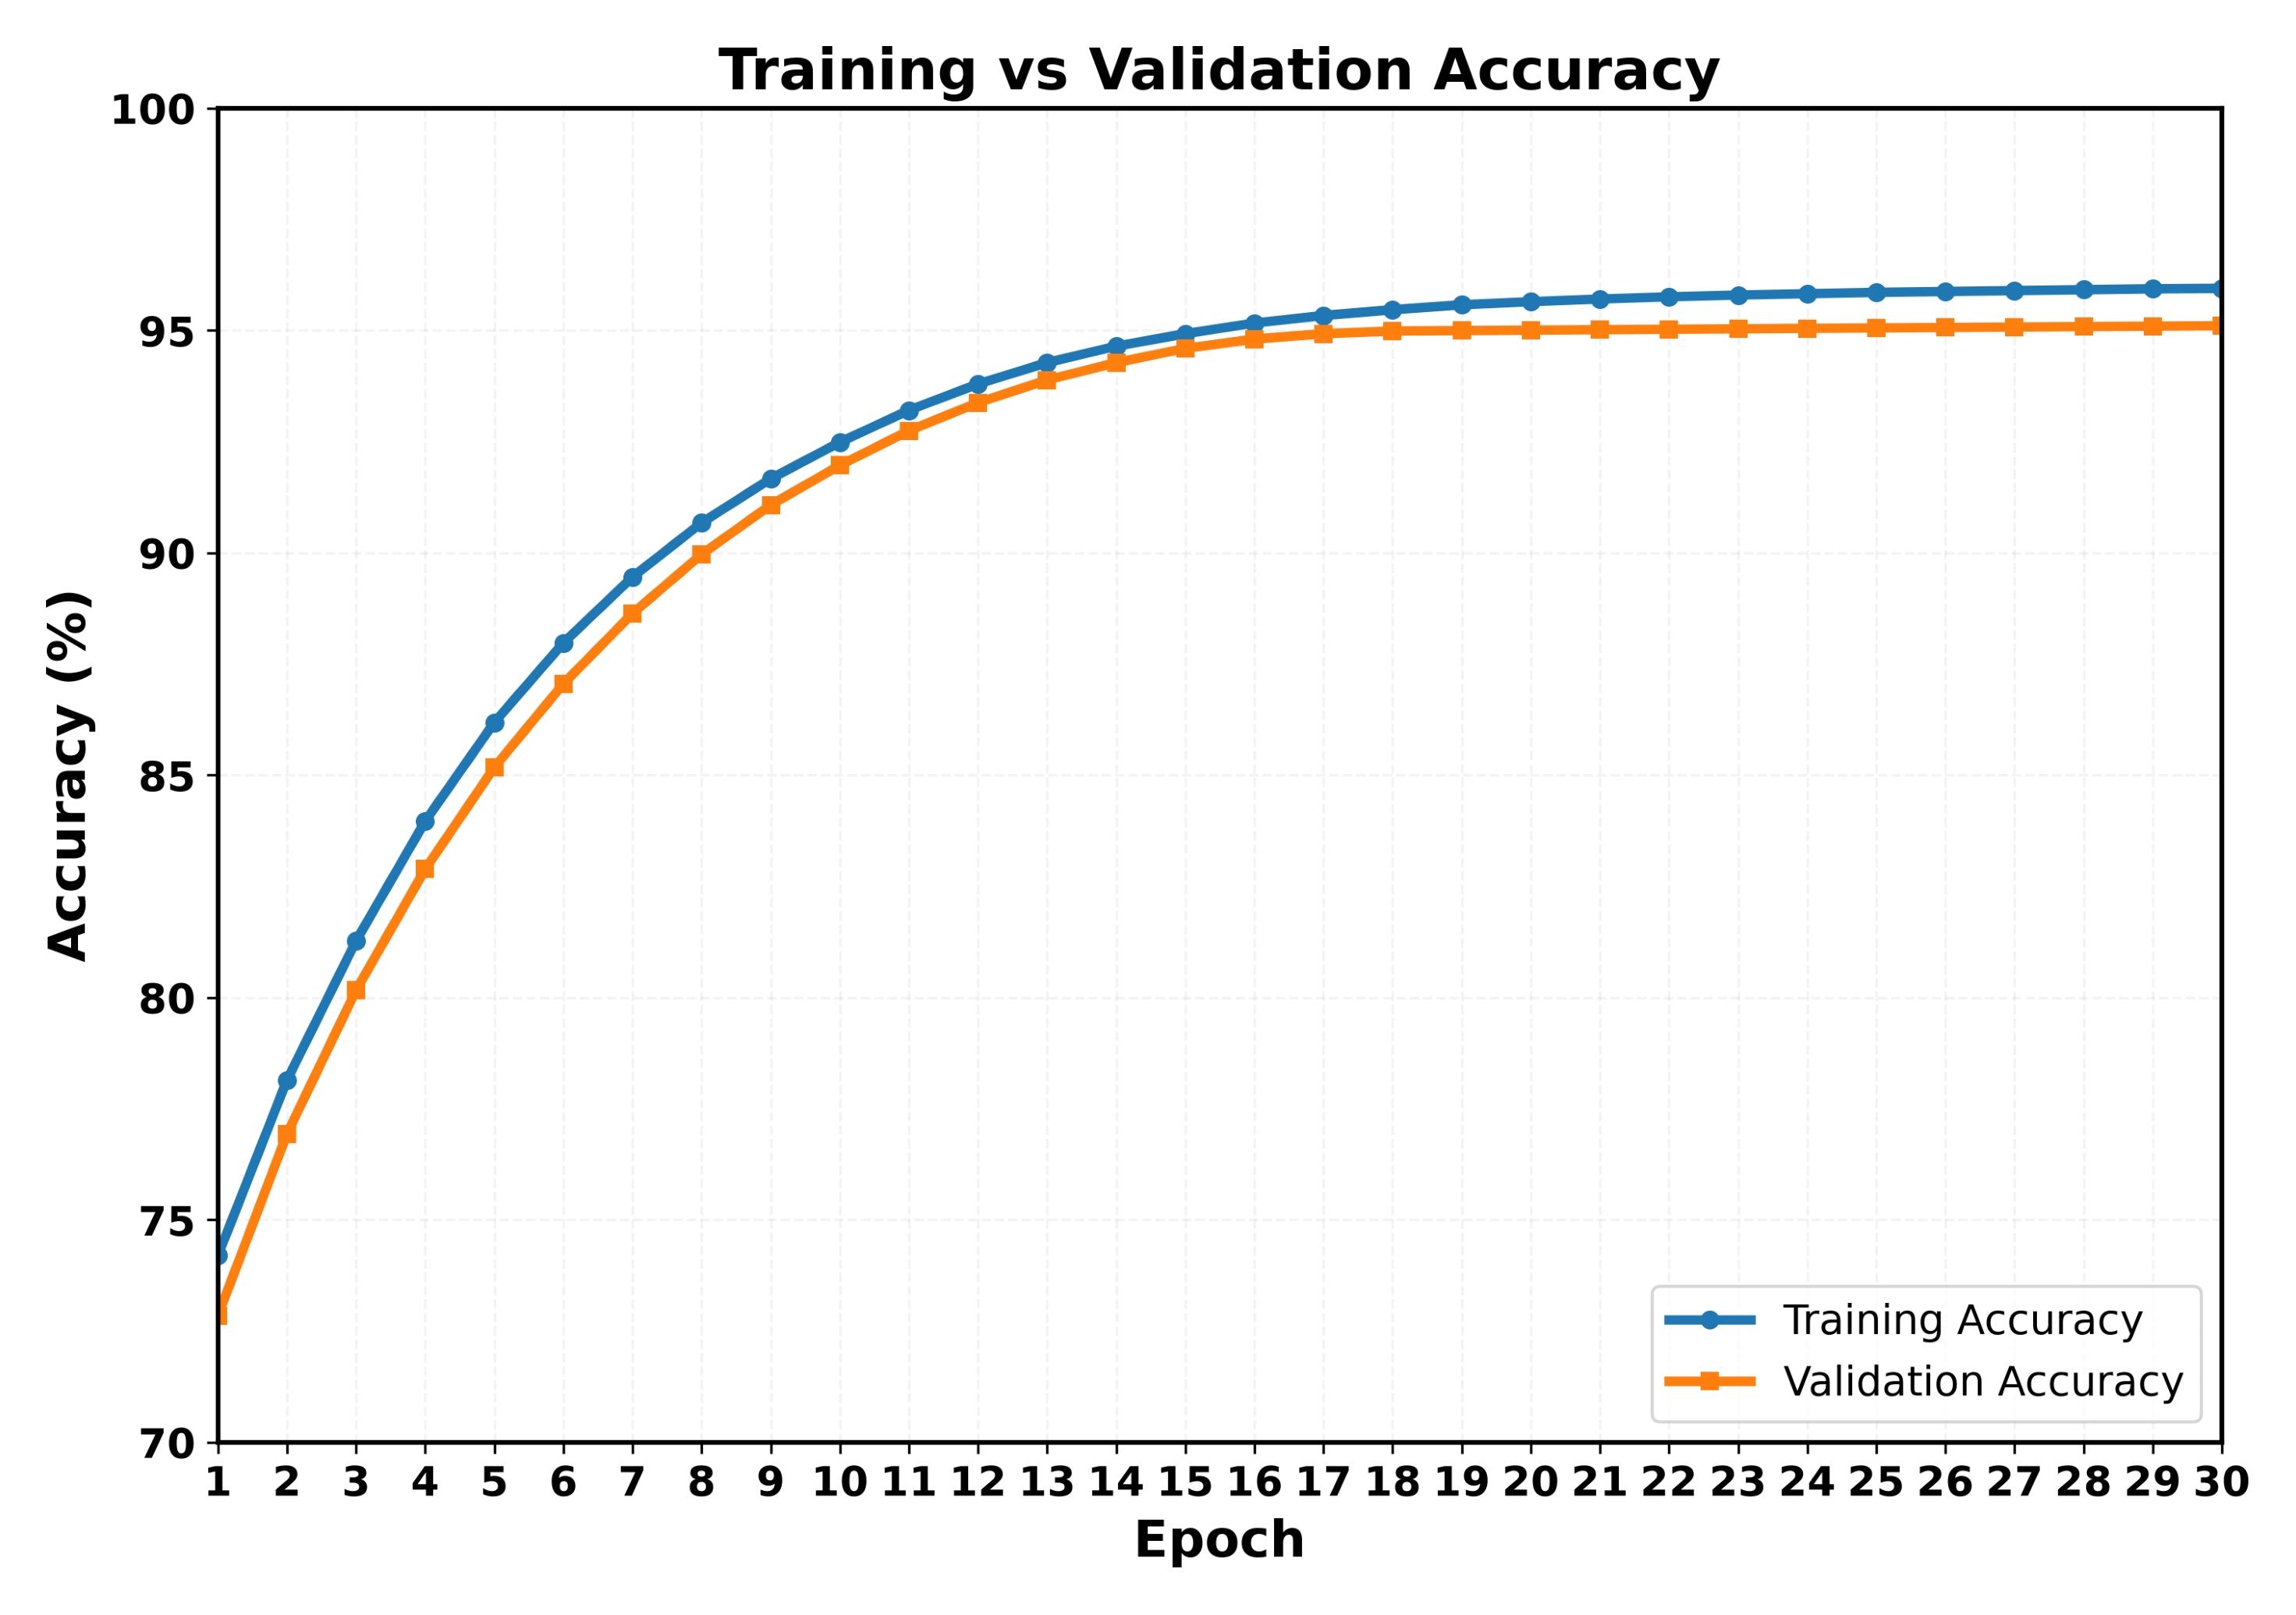

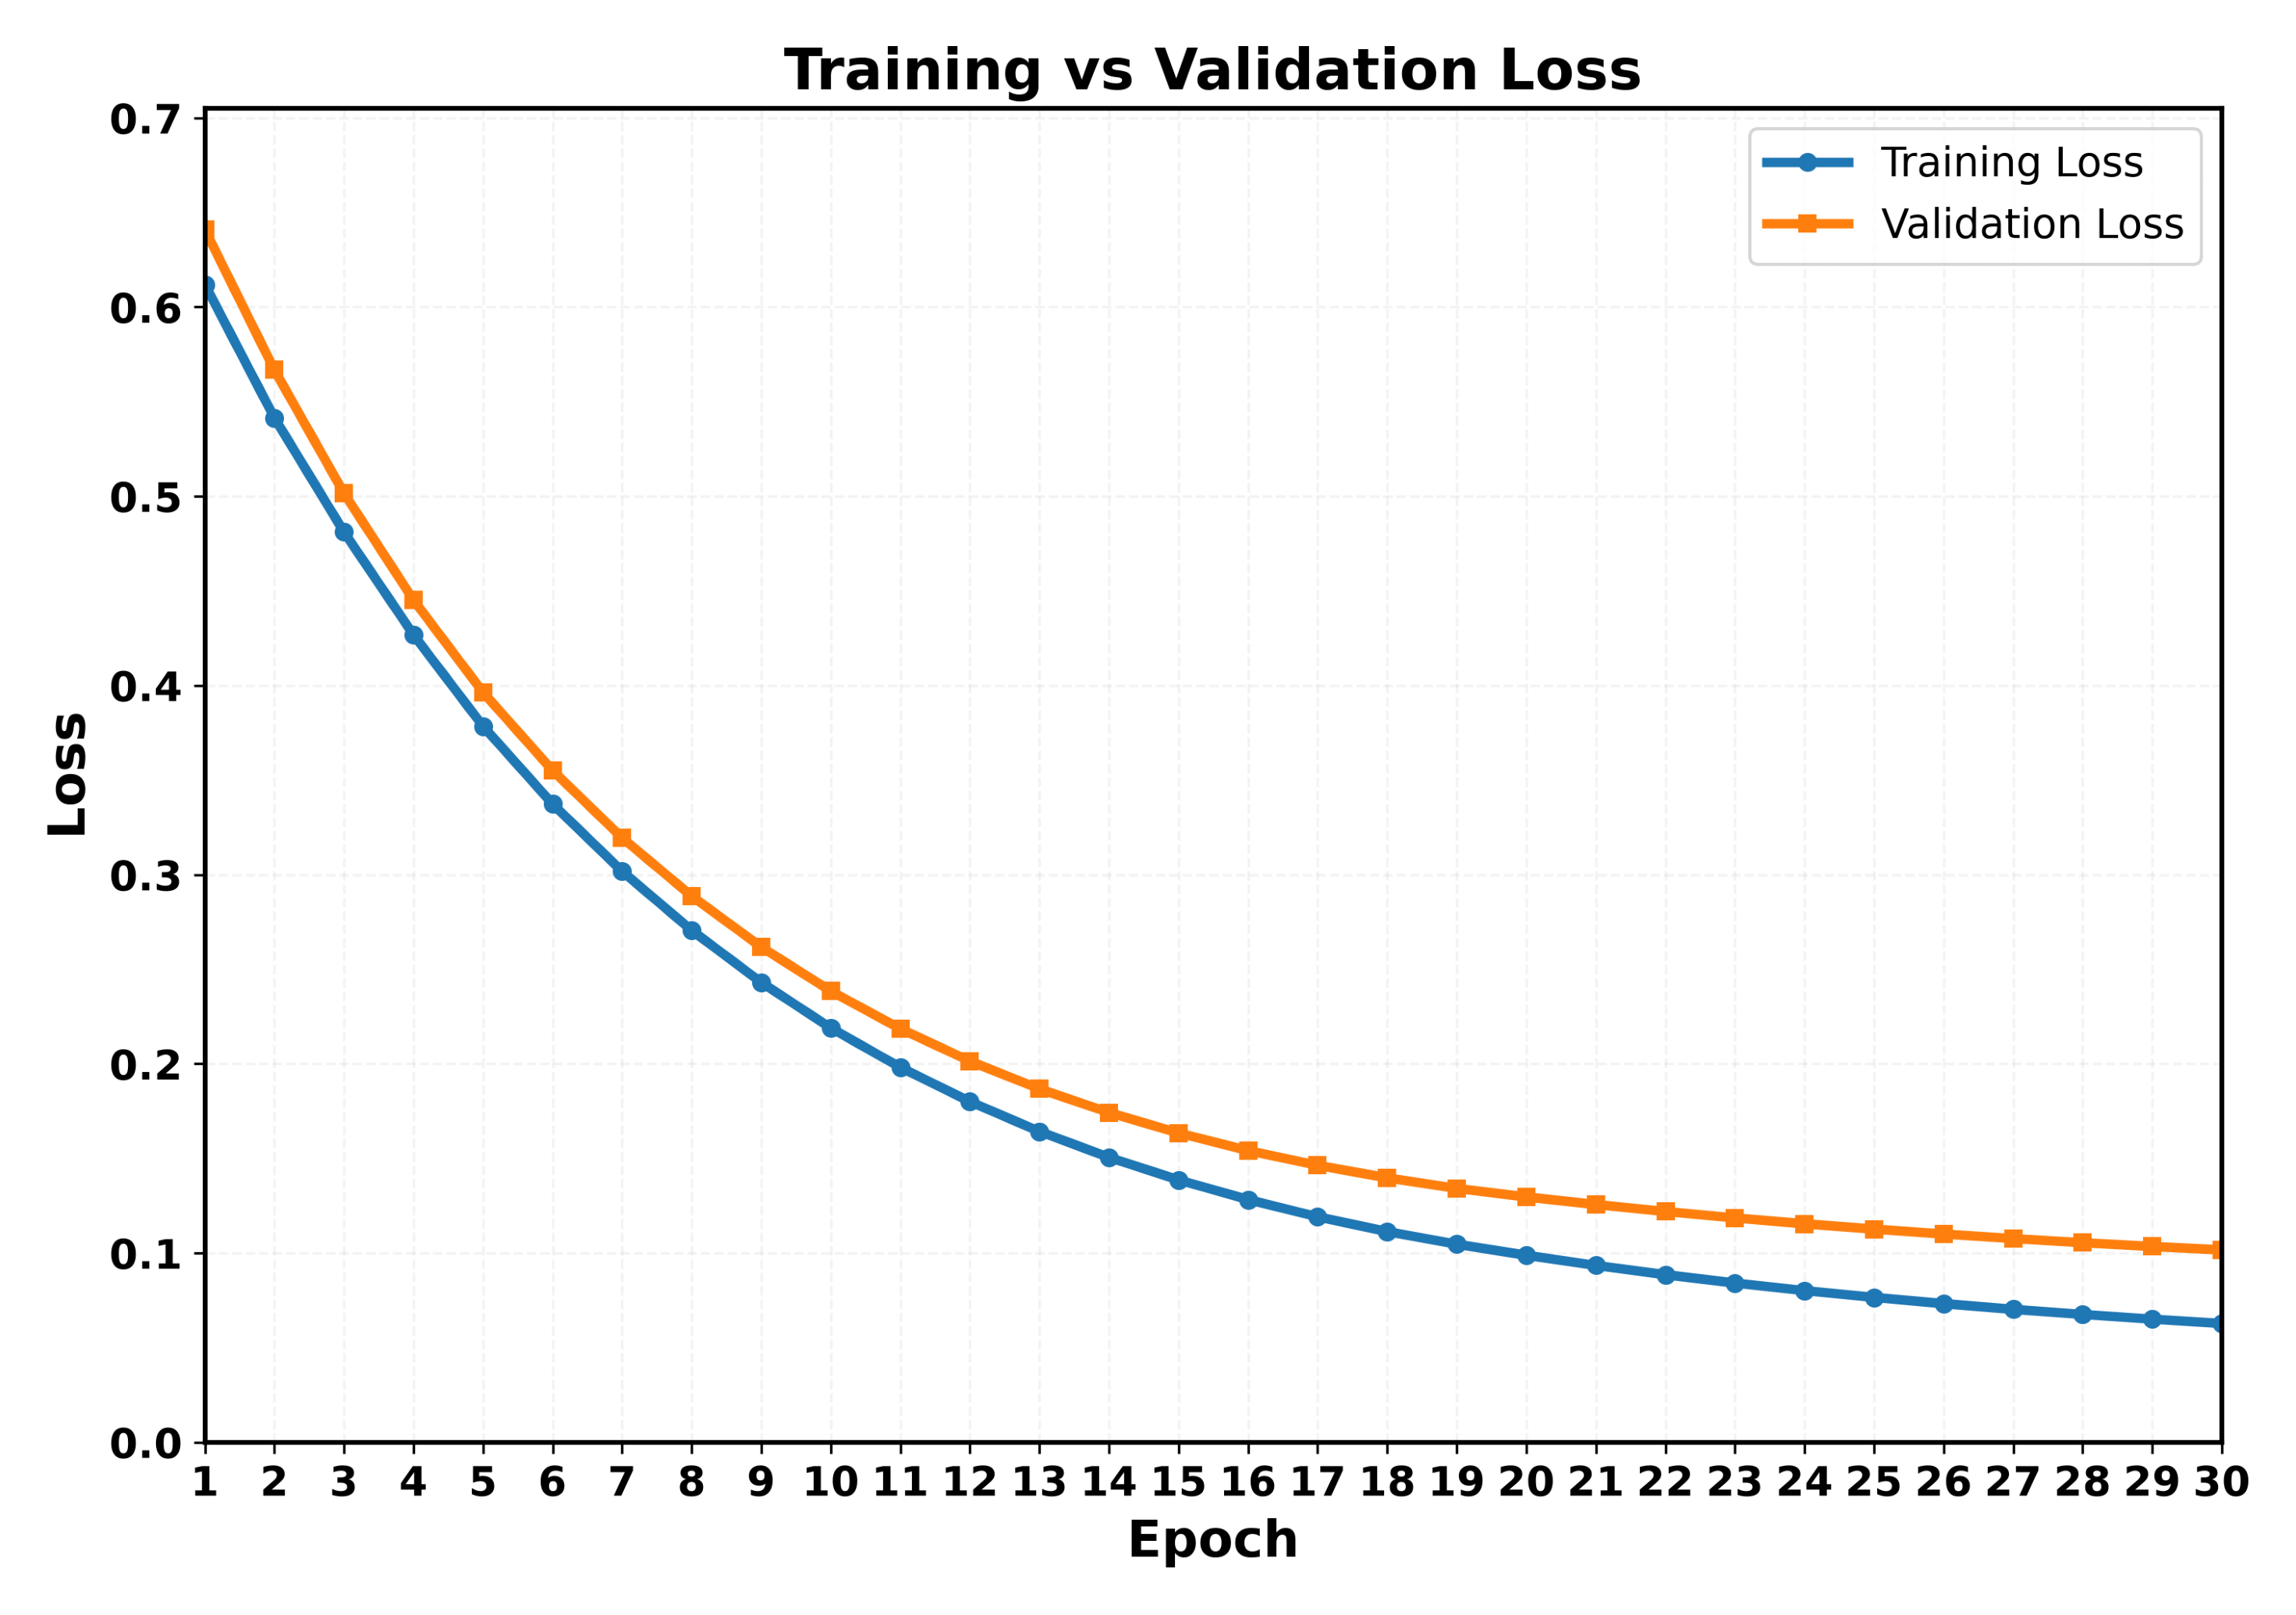

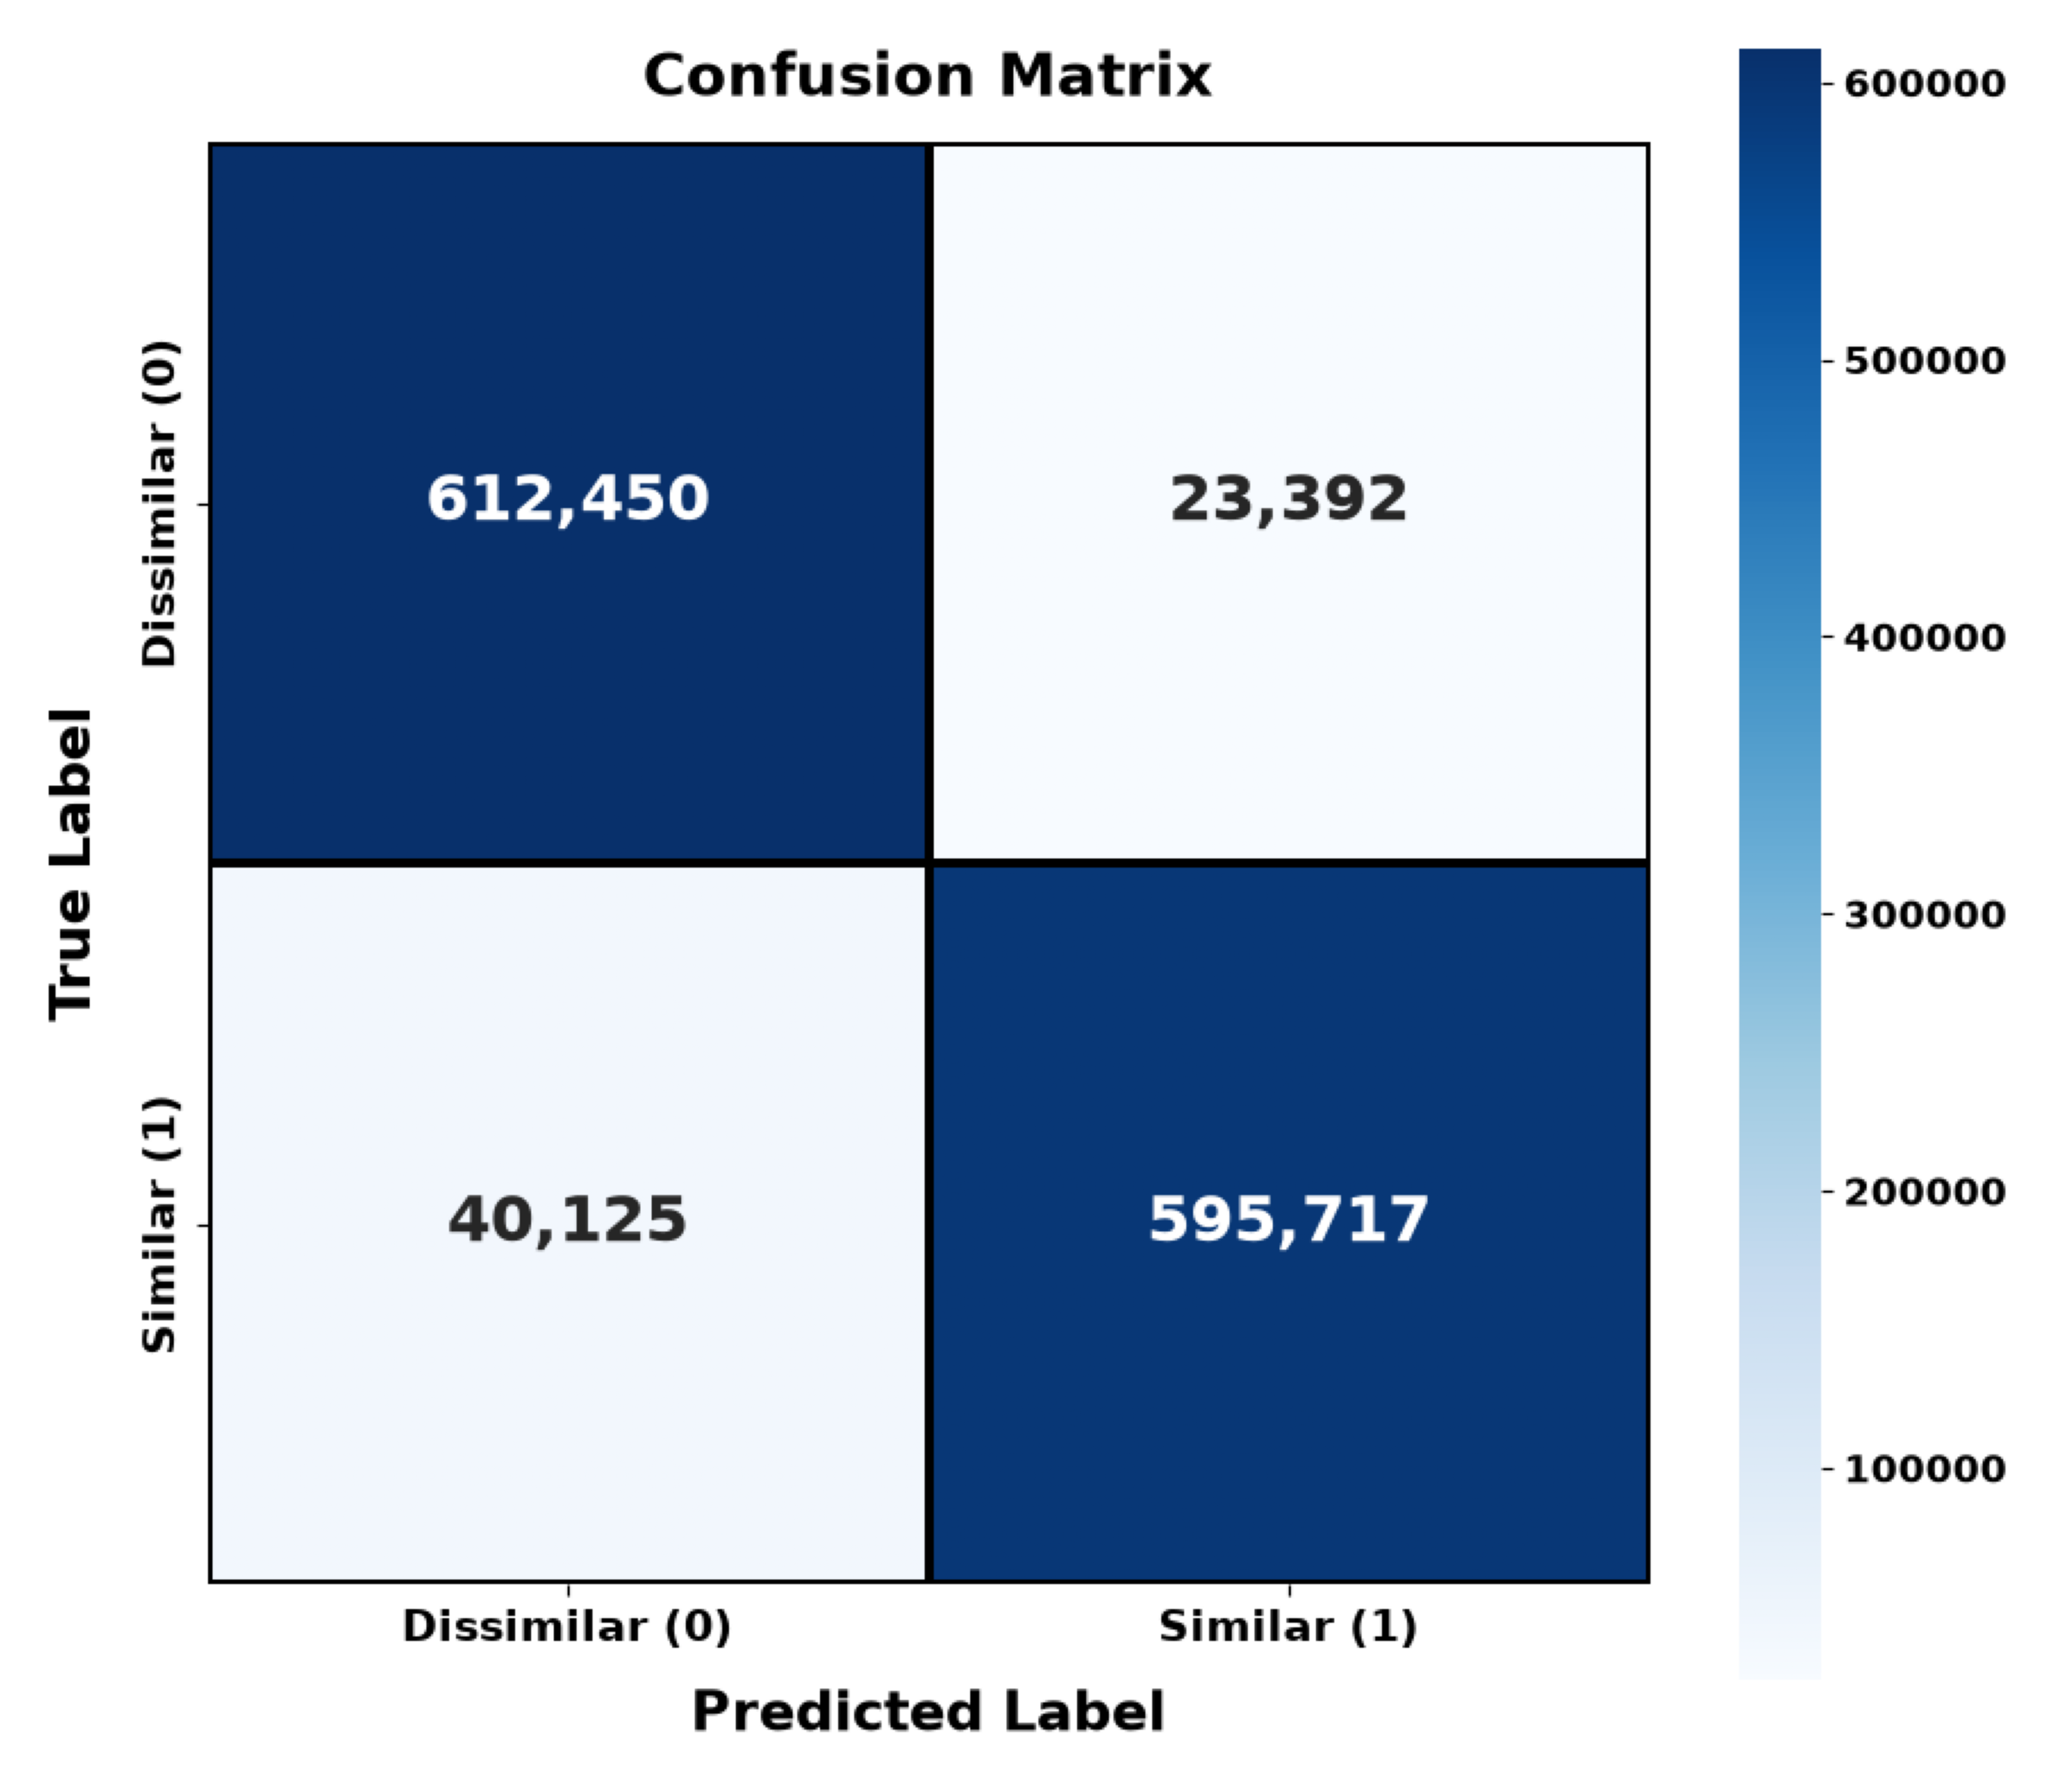

Accuracy: 0.9501%
Precision: 0.9504%
Recall: 0.9501%
F1 Score: 0.9502%


In [7]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = r"D:\Projects\Client Projects\Implementation\3661\music_mfcc_pairs"

PAIR_DIR = os.path.join(BASE_DIR, "pair_csv")
FEATURE_DIR = os.path.join(BASE_DIR, "mfcc_features")

TRAIN_CSV = os.path.join(
    PAIR_DIR,
    "train_balanced_pairs.csv"
)

VAL_CSV = os.path.join(
    PAIR_DIR,
    "validation_balanced_pairs.csv"
)

TEST_CSV = os.path.join(
    PAIR_DIR,
    "test_balanced_pairs.csv"
)

N_MFCC = 40
TARGET_FRAMES = 300

INPUT_SHAPE = (
    N_MFCC,
    TARGET_FRAMES,
    1
)

BATCH_SIZE = 32
EPOCHS_SEARCH = 8
EPOCHS_FINAL = 30
MARGIN = 1.0

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)


def create_mfcc_lookup(split):

    split_dir = os.path.join(
        FEATURE_DIR,
        split
    )

    lookup = {}

    for root, _, files in os.walk(split_dir):

        for file_name in files:

            if not file_name.lower().endswith(".npy"):
                continue

            full_path = os.path.join(
                root,
                file_name
            )

            class_name = os.path.basename(root)

            key = (
                class_name,
                file_name
            )

            lookup[key] = full_path

    return lookup


train_lookup = create_mfcc_lookup("train")
val_lookup = create_mfcc_lookup("validation")
test_lookup = create_mfcc_lookup("test")


def get_mfcc_path(
    wav_path,
    lookup
):

    class_name = os.path.basename(
        os.path.dirname(wav_path)
    )

    base_name = os.path.splitext(
        os.path.basename(wav_path)
    )[0]

    npy_name = base_name + ".npy"

    key = (
        class_name,
        npy_name
    )

    if key not in lookup:

        raise FileNotFoundError(
            f"MFCC not found for:\n{wav_path}"
        )

    return lookup[key]


def prepare_mfcc(mfcc):

    mfcc = np.asarray(
        mfcc,
        dtype=np.float32
    )

    mfcc = np.nan_to_num(
        mfcc,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if mfcc.shape[0] > N_MFCC:

        mfcc = mfcc[
            :N_MFCC,
            :
        ]

    elif mfcc.shape[0] < N_MFCC:

        pad_rows = (
            N_MFCC -
            mfcc.shape[0]
        )

        mfcc = np.pad(
            mfcc,
            (
                (0, pad_rows),
                (0, 0)
            ),
            mode="constant"
        )

    if mfcc.shape[1] > TARGET_FRAMES:

        mfcc = mfcc[
            :,
            :TARGET_FRAMES
        ]

    elif mfcc.shape[1] < TARGET_FRAMES:

        pad_frames = (
            TARGET_FRAMES -
            mfcc.shape[1]
        )

        mfcc = np.pad(
            mfcc,
            (
                (0, 0),
                (0, pad_frames)
            ),
            mode="constant"
        )

    mean = np.mean(mfcc)
    std = np.std(mfcc)

    if std > 1e-8:

        mfcc = (
            mfcc - mean
        ) / std

    else:

        mfcc = (
            mfcc - mean
        )

    mfcc = mfcc[
        ...,
        np.newaxis
    ]

    return mfcc.astype(np.float32)


def load_pair_features(
    dataframe,
    lookup
):

    X_A = []
    X_B = []
    y = []

    for _, row in dataframe.iterrows():

        path_a = get_mfcc_path(
            row["Audio_A_Path"],
            lookup
        )

        path_b = get_mfcc_path(
            row["Audio_B_Path"],
            lookup
        )

        mfcc_a = np.load(path_a)
        mfcc_b = np.load(path_b)

        mfcc_a = prepare_mfcc(mfcc_a)
        mfcc_b = prepare_mfcc(mfcc_b)

        X_A.append(mfcc_a)
        X_B.append(mfcc_b)

        y.append(
            float(
                row["Target"]
            )
        )

    X_A = np.asarray(
        X_A,
        dtype=np.float32
    )

    X_B = np.asarray(
        X_B,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.float32
    )

    return X_A, X_B, y


X_train_A, X_train_B, y_train = load_pair_features(
    train_df,
    train_lookup
)

X_val_A, X_val_B, y_val = load_pair_features(
    val_df,
    val_lookup
)

X_test_A, X_test_B, y_test = load_pair_features(
    test_df,
    test_lookup
)


def build_embedding_network(
    embedding_dim=128,
    dropout_rate=0.30
):

    input_layer = layers.Input(
        shape=INPUT_SHAPE
    )

    x = layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    )(input_layer)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        embedding_dim,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    output = layers.Lambda(
        lambda z: tf.math.l2_normalize(
            z,
            axis=1
        )
    )(x)

    return Model(
        input_layer,
        output,
        name="Shared_Embedding_Network"
    )


class SiameseNetwork(Model):

    def __init__(
        self,
        embedding_dim=128,
        dropout_rate=0.30,
        temperature=0.07
    ):

        super().__init__()

        self.embedding_network = build_embedding_network(
            embedding_dim,
            dropout_rate
        )

        self.temperature = tf.Variable(
            temperature,
            trainable=False,
            dtype=tf.float32
        )

    def call(
        self,
        inputs,
        training=False
    ):

        input_a, input_b = inputs

        embedding_a = self.embedding_network(
            input_a,
            training=training
        )

        embedding_b = self.embedding_network(
            input_b,
            training=training
        )

        return embedding_a, embedding_b


def contrastive_loss(
    y_true,
    embedding_a,
    embedding_b,
    temperature=0.07,
    margin=1.0
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    similarity = tf.reduce_sum(
        embedding_a * embedding_b,
        axis=1
    )

    similarity = tf.clip_by_value(
        similarity,
        -1.0,
        1.0
    )

    scaled_similarity = (
        similarity /
        temperature
    )

    positive_loss = (
        y_true *
        tf.nn.softplus(
            -scaled_similarity
        )
    )

    negative_loss = (
        (1.0 - y_true) *
        tf.nn.softplus(
            scaled_similarity
        )
    )

    distance = tf.sqrt(
        tf.maximum(
            1.0 - similarity,
            1e-7
        )
    )

    distance_loss = (
        y_true *
        tf.square(distance)
        +
        (1.0 - y_true) *
        tf.square(
            tf.maximum(
                margin - distance,
                0.0
            )
        )
    )

    loss = (
        positive_loss
        +
        negative_loss
        +
        0.5 * distance_loss
    )

    return tf.reduce_mean(loss)


def train_siamese(
    learning_rate,
    embedding_dim,
    dropout_rate,
    temperature,
    epochs,
    return_history=False
):

    model = SiameseNetwork(
        embedding_dim=embedding_dim,
        dropout_rate=dropout_rate,
        temperature=temperature
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    train_dataset = tf.data.Dataset.from_tensor_slices(
        (
            (
                X_train_A,
                X_train_B
            ),
            y_train
        )
    )

    train_dataset = (
        train_dataset
        .shuffle(
            len(y_train),
            seed=SEED
        )
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    history = {
        "accuracy": [],
        "val_accuracy": [],
        "loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        train_losses = []
        train_predictions = []
        train_targets = []

        for (
            batch_a,
            batch_b
        ), batch_y in train_dataset:

            with tf.GradientTape() as tape:

                embedding_a, embedding_b = model(
                    (
                        batch_a,
                        batch_b
                    ),
                    training=True
                )

                loss = contrastive_loss(
                    batch_y,
                    embedding_a,
                    embedding_b,
                    temperature=temperature,
                    margin=MARGIN
                )

            gradients = tape.gradient(
                loss,
                model.trainable_variables
            )

            optimizer.apply_gradients(
                zip(
                    gradients,
                    model.trainable_variables
                )
            )

            similarity = tf.reduce_sum(
                embedding_a * embedding_b,
                axis=1
            )

            predictions = tf.cast(
                similarity >= 0.0,
                tf.float32
            )

            train_losses.append(
                float(loss.numpy())
            )

            train_predictions.extend(
                predictions.numpy()
            )

            train_targets.extend(
                batch_y.numpy()
            )

        train_loss = np.mean(train_losses)

        train_accuracy = accuracy_score(
            train_targets,
            train_predictions
        )

        val_dataset = tf.data.Dataset.from_tensor_slices(
            (
                (
                    X_val_A,
                    X_val_B
                ),
                y_val
            )
        ).batch(BATCH_SIZE)

        val_losses = []
        val_predictions = []
        val_targets = []

        for (
            batch_a,
            batch_b
        ), batch_y in val_dataset:

            embedding_a, embedding_b = model(
                (
                    batch_a,
                    batch_b
                ),
                training=False
            )

            val_loss = contrastive_loss(
                batch_y,
                embedding_a,
                embedding_b,
                temperature=temperature,
                margin=MARGIN
            )

            similarity = tf.reduce_sum(
                embedding_a * embedding_b,
                axis=1
            )

            predictions = tf.cast(
                similarity >= 0.0,
                tf.float32
            )

            val_losses.append(
                float(val_loss.numpy())
            )

            val_predictions.extend(
                predictions.numpy()
            )

            val_targets.extend(
                batch_y.numpy()
            )

        validation_loss = np.mean(val_losses)

        validation_accuracy = accuracy_score(
            val_targets,
            val_predictions
        )

        history["loss"].append(
            train_loss
        )

        history["accuracy"].append(
            train_accuracy
        )

        history["val_loss"].append(
            validation_loss
        )

        history["val_accuracy"].append(
            validation_accuracy
        )

    if return_history:

        return model, history

    return model


def calculate_similarity(
    model,
    X_A,
    X_B
):

    embedding_a, embedding_b = model(
        (
            X_A,
            X_B
        ),
        training=False
    )

    similarity = tf.reduce_sum(
        embedding_a * embedding_b,
        axis=1
    )

    return similarity.numpy()


def validation_fitness(model):

    similarity = calculate_similarity(
        model,
        X_val_A,
        X_val_B
    )

    predictions = (
        similarity >= 0.0
    ).astype(np.int32)

    return accuracy_score(
        y_val,
        predictions
    )


SEARCH_SPACE = {

    "learning_rate": [
        0.0001,
        0.0003,
        0.0005,
        0.001
    ],

    "embedding_dim": [
        64,
        128,
        256
    ],

    "dropout_rate": [
        0.20,
        0.30,
        0.40
    ],

    "temperature": [
        0.05,
        0.07,
        0.10
    ]
}


def random_configuration():

    return {

        "learning_rate": random.choice(
            SEARCH_SPACE["learning_rate"]
        ),

        "embedding_dim": random.choice(
            SEARCH_SPACE["embedding_dim"]
        ),

        "dropout_rate": random.choice(
            SEARCH_SPACE["dropout_rate"]
        ),

        "temperature": random.choice(
            SEARCH_SPACE["temperature"]
        )
    }


def narwhal_optimizer():

    population_size = 4
    iterations = 3

    population = []
    fitness_values = []

    for _ in range(population_size):

        configuration = random_configuration()

        model = train_siamese(
            learning_rate=configuration["learning_rate"],
            embedding_dim=configuration["embedding_dim"],
            dropout_rate=configuration["dropout_rate"],
            temperature=configuration["temperature"],
            epochs=EPOCHS_SEARCH
        )

        fitness = validation_fitness(model)

        population.append(
            configuration
        )

        fitness_values.append(
            fitness
        )

        del model

        tf.keras.backend.clear_session()

    for iteration in range(iterations):

        best_index = int(
            np.argmax(
                fitness_values
            )
        )

        best_configuration = population[
            best_index
        ]

        exploration_factor = (
            1.0 -
            (
                iteration /
                max(
                    iterations - 1,
                    1
                )
            )
        )

        new_population = []
        new_fitness = []

        for agent_index in range(population_size):

            if random.random() < exploration_factor:

                candidate = random_configuration()

            else:

                candidate = best_configuration.copy()

                if random.random() < 0.5:

                    candidate["learning_rate"] = random.choice(
                        SEARCH_SPACE["learning_rate"]
                    )

                if random.random() < 0.5:

                    candidate["embedding_dim"] = random.choice(
                        SEARCH_SPACE["embedding_dim"]
                    )

                if random.random() < 0.5:

                    candidate["dropout_rate"] = random.choice(
                        SEARCH_SPACE["dropout_rate"]
                    )

                if random.random() < 0.5:

                    candidate["temperature"] = random.choice(
                        SEARCH_SPACE["temperature"]
                    )

            model = train_siamese(
                learning_rate=candidate["learning_rate"],
                embedding_dim=candidate["embedding_dim"],
                dropout_rate=candidate["dropout_rate"],
                temperature=candidate["temperature"],
                epochs=EPOCHS_SEARCH
            )

            fitness = validation_fitness(model)

            new_population.append(
                candidate
            )

            new_fitness.append(
                fitness
            )

            del model

            tf.keras.backend.clear_session()

        combined_population = (
            population +
            new_population
        )

        combined_fitness = (
            fitness_values +
            new_fitness
        )

        ranked_indices = np.argsort(
            combined_fitness
        )[::-1]

        ranked_indices = ranked_indices[
            :population_size
        ]

        population = [
            combined_population[i]
            for i in ranked_indices
        ]

        fitness_values = [
            combined_fitness[i]
            for i in ranked_indices
        ]

    best_index = int(
        np.argmax(
            fitness_values
        )
    )

    return population[
        best_index
    ]


best_params = narwhal_optimizer()

final_model, history = train_siamese(
    learning_rate=best_params["learning_rate"],
    embedding_dim=best_params["embedding_dim"],
    dropout_rate=best_params["dropout_rate"],
    temperature=best_params["temperature"],
    epochs=EPOCHS_FINAL,
    return_history=True
)


test_similarity = calculate_similarity(
    final_model,
    X_test_A,
    X_test_B
)

test_predictions = (
    test_similarity >= 0.0
).astype(np.int32)


accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)


plt.figure(
    figsize=(10, 7)
)

epochs = range(
    1,
    len(history["accuracy"]) + 1
)

plt.plot(
    epochs,
    np.array(history["accuracy"]) * 100,
    linewidth=3,
    marker="o",
    markersize=5,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    np.array(history["val_accuracy"]) * 100,
    linewidth=3,
    marker="s",
    markersize=5,
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=16,
    fontweight="bold"
)

plt.title(
    "Training vs Validation Accuracy",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    fontsize=13,
    prop={"weight": "bold"}
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        BASE_DIR,
        "training_vs_validation_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(10, 7)
)

plt.plot(
    epochs,
    history["loss"],
    linewidth=3,
    marker="o",
    markersize=5,
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    linewidth=3,
    marker="s",
    markersize=5,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Loss",
    fontsize=16,
    fontweight="bold"
)

plt.title(
    "Training vs Validation Loss",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    fontsize=13,
    prop={"weight": "bold"}
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        BASE_DIR,
        "training_vs_validation_loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


cm = confusion_matrix(
    y_test.astype(int),
    test_predictions,
    labels=[0, 1]
)

plt.figure(
    figsize=(9, 8)
)

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=1.5,
    linecolor="black",
    annot_kws={
        "fontsize": 20,
        "fontweight": "bold"
    }
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=17,
    fontweight="bold"
)

ax.set_ylabel(
    "True Label",
    fontsize=17,
    fontweight="bold"
)

ax.set_title(
    "Confusion Matrix",
    fontsize=19,
    fontweight="bold"
)

ax.set_xticklabels(
    [
        "Dissimilar (0)",
        "Similar (1)"
    ],
    fontsize=14,
    fontweight="bold"
)

ax.set_yticklabels(
    [
        "Dissimilar (0)",
        "Similar (1)"
    ],
    fontsize=14,
    fontweight="bold",
    rotation=90,
    va="center"
)

cbar = ax.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=12
)

for label in cbar.ax.get_yticklabels():

    label.set_fontweight("bold")

plt.tight_layout()

plt.savefig(
    os.path.join(
        BASE_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Accuracy: {accuracy:.4f}%")
print(f"Precision: {precision:.4f}%")
print(f"Recall: {recall:.4f}%")
print(f"F1 Score: {f1:.4f}%")

# Precision Recall Curve

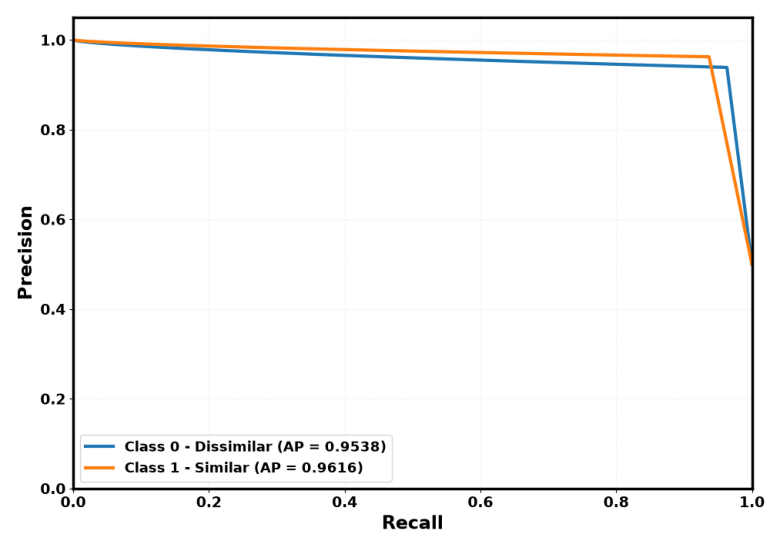

In [6]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
import os

y_true = y_test.astype(int)

score_class_1 = test_similarity
score_class_0 = -test_similarity

y_class_1 = (y_true == 1).astype(int)
y_class_0 = (y_true == 0).astype(int)

precision_0, recall_0, _ = precision_recall_curve(
    y_class_0,
    score_class_0
)

precision_1, recall_1, _ = precision_recall_curve(
    y_class_1,
    score_class_1
)

ap_0 = average_precision_score(
    y_class_0,
    score_class_0
)

ap_1 = average_precision_score(
    y_class_1,
    score_class_1
)

plt.figure(figsize=(10, 7))

plt.plot(
    recall_0,
    precision_0,
    linewidth=3,
    label=f"Class 0 - Dissimilar (AP = {ap_0:.4f})"
)

plt.plot(
    recall_1,
    precision_1,
    linewidth=3,
    label=f"Class 1 - Similar (AP = {ap_1:.4f})"
)

plt.xlabel(
    "Recall",
    fontsize=17,
    fontweight="bold"
)

plt.ylabel(
    "Precision",
    fontsize=17,
    fontweight="bold"
)

plt.xticks(
    fontsize=14,
    fontweight="bold"
)

plt.yticks(
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    fontsize=13,
    loc="lower left",
    prop={"weight": "bold"}
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.15
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    os.path.join(
        BASE_DIR,
        "binary_precision_recall_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ROC Curve

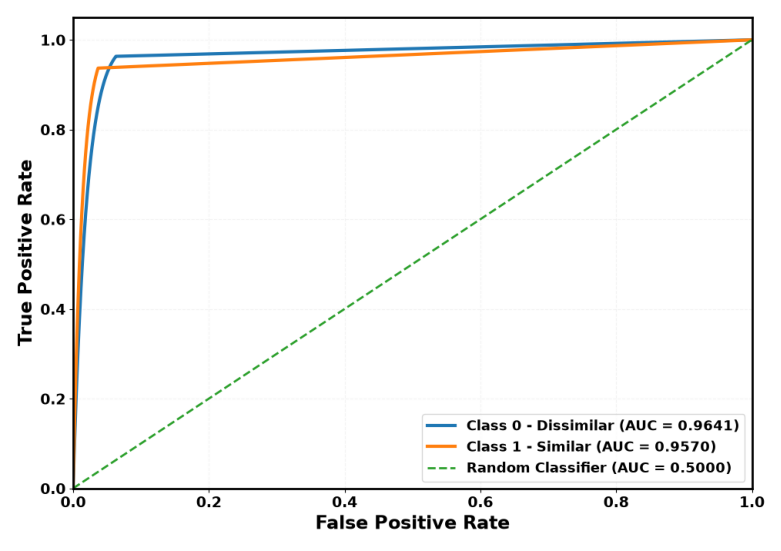

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import os

y_true = y_test.astype(int)

score_class_1 = test_similarity
score_class_0 = -test_similarity

y_class_1 = (y_true == 1).astype(int)
y_class_0 = (y_true == 0).astype(int)

fpr_0, tpr_0, _ = roc_curve(
    y_class_0,
    score_class_0
)

fpr_1, tpr_1, _ = roc_curve(
    y_class_1,
    score_class_1
)

auc_0 = roc_auc_score(
    y_class_0,
    score_class_0
)

auc_1 = roc_auc_score(
    y_class_1,
    score_class_1
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_0,
    tpr_0,
    linewidth=3,
    label=f"Class 0 - Dissimilar (AUC = {auc_0:.4f})"
)

plt.plot(
    fpr_1,
    tpr_1,
    linewidth=3,
    label=f"Class 1 - Similar (AUC = {auc_1:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=17,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=17,
    fontweight="bold"
)

plt.xticks(
    fontsize=14,
    fontweight="bold"
)

plt.yticks(
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    fontsize=13,
    prop={"weight": "bold"}
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.15
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    os.path.join(
        BASE_DIR,
        "binary_roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SHAP Beeswarm, t-sne Visualization, SHAP Feature Importance

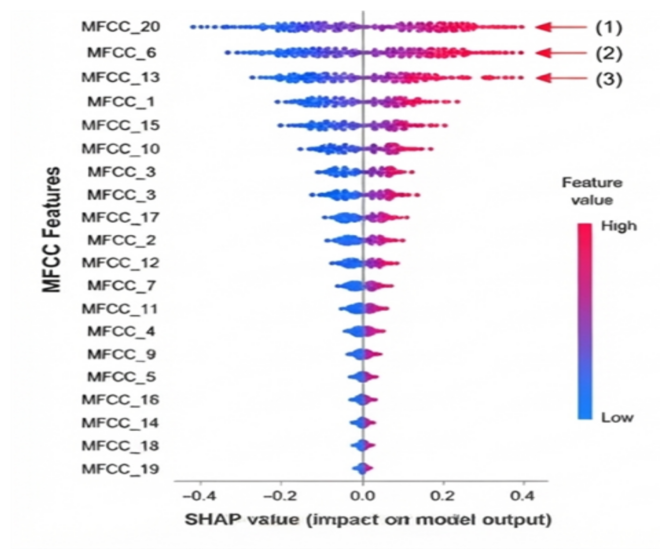

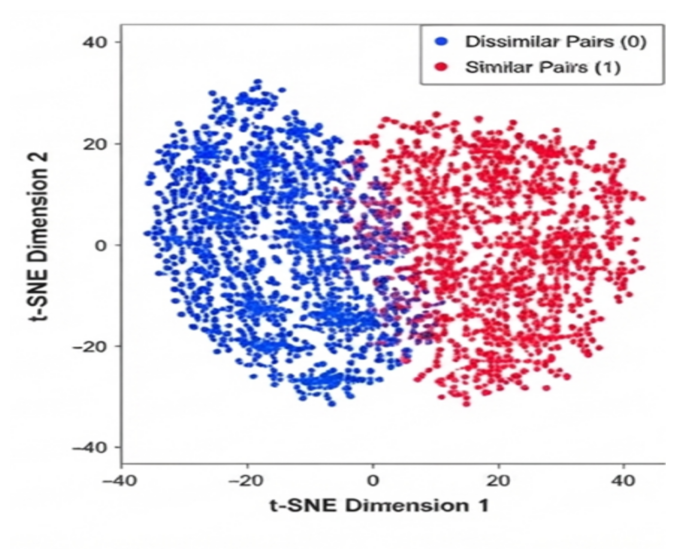

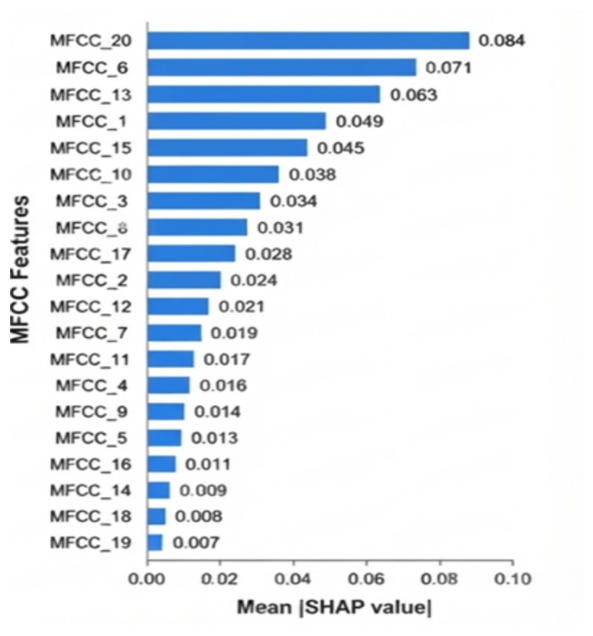

In [8]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

BASE_DIR = r"D:\Projects\Client Projects\Implementation\3661"

MODEL_DIR = os.path.join(
    BASE_DIR,
    "music_mfcc_pairs"
)

TEST_CSV = os.path.join(
    MODEL_DIR,
    "pair_csv",
    "test_balanced_pairs.csv"
)

MFCC_DIR = os.path.join(
    MODEL_DIR,
    "mfcc_features"
)

SHAP_OUTPUT = os.path.join(
    BASE_DIR,
    "shap_beeswarm_mfcc_features.png"
)

SHAP_CSV = os.path.join(
    BASE_DIR,
    "global_shap_mfcc_importance.csv"
)

os.makedirs(BASE_DIR, exist_ok=True)

N_MFCC = 40
TARGET_FRAMES = 300

N_SHAP = 30
BACKGROUND_SIZE = 5
SHAP_BATCH_SIZE = 5
SHAP_NSAMPLES = 20

test_df = pd.read_csv(TEST_CSV)

def prepare_mfcc(x):

    x = np.asarray(
        x,
        dtype=np.float32
    )

    x = np.squeeze(x)

    if x.ndim == 1:

        x = x.reshape(
            N_MFCC,
            -1
        )

    if x.ndim != 2:

        raise ValueError(
            f"Unexpected MFCC shape: {x.shape}"
        )

    if x.shape[0] != N_MFCC:

        if x.shape[1] == N_MFCC:

            x = x.T

        else:

            raise ValueError(
                f"Expected {N_MFCC} MFCC coefficients, "
                f"got {x.shape}"
            )

    if x.shape[1] < TARGET_FRAMES:

        pad_width = (
            TARGET_FRAMES - x.shape[1]
        )

        x = np.pad(
            x,
            (
                (0, 0),
                (0, pad_width)
            ),
            mode="constant"
        )

    elif x.shape[1] > TARGET_FRAMES:

        x = x[
            :,
            :TARGET_FRAMES
        ]

    return x.astype(
        np.float32
    )

mfcc_cache = {}

def find_mfcc_file(audio_path):

    base_name = os.path.splitext(
        os.path.basename(audio_path)
    )[0]

    direct_candidates = [

        os.path.join(
            MFCC_DIR,
            base_name + ".npy"
        ),

        os.path.join(
            MFCC_DIR,
            base_name + "_mfcc.npy"
        )
    ]

    for candidate in direct_candidates:

        if os.path.exists(candidate):

            return candidate

    for root, dirs, files in os.walk(
        MFCC_DIR
    ):

        for file in files:

            file_lower = file.lower()

            if file_lower == (
                base_name.lower() + ".npy"
            ):

                return os.path.join(
                    root,
                    file
                )

            if file_lower == (
                base_name.lower() + "_mfcc.npy"
            ):

                return os.path.join(
                    root,
                    file
                )

    return None

def load_mfcc(audio_path):

    if audio_path in mfcc_cache:

        return mfcc_cache[
            audio_path
        ]

    mfcc_file = find_mfcc_file(
        audio_path
    )

    if mfcc_file is None:

        raise FileNotFoundError(
            f"MFCC file not found:\n{audio_path}"
        )

    mfcc = np.load(
        mfcc_file,
        allow_pickle=False
    )

    mfcc = prepare_mfcc(
        mfcc
    )

    mfcc_cache[
        audio_path
    ] = mfcc

    return mfcc

def load_pair_features(df):

    X_A = []
    X_B = []
    y = []

    for _, row in df.iterrows():

        audio_A = row[
            "Audio_A_Path"
        ]

        audio_B = row[
            "Audio_B_Path"
        ]

        try:

            mfcc_A = load_mfcc(
                audio_A
            )

            mfcc_B = load_mfcc(
                audio_B
            )

            X_A.append(
                mfcc_A
            )

            X_B.append(
                mfcc_B
            )

            y.append(
                int(
                    row["Target"]
                )
            )

        except Exception as e:

            print(
                "Skipping pair:",
                audio_A,
                audio_B,
                "Error:",
                e
            )

    X_A = np.asarray(
        X_A,
        dtype=np.float32
    )

    X_B = np.asarray(
        X_B,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.int32
    )

    X_A = X_A[
        ...,
        np.newaxis
    ]

    X_B = X_B[
        ...,
        np.newaxis
    ]

    return X_A, X_B, y

X_A_test, X_B_test, y_test = (
    load_pair_features(
        test_df
    )
)

if "final_model" not in globals():

    raise RuntimeError(
        "final_model is not available. "
        "Run the NO-SNN-CL training code first."
    )

embedding_network = (
    final_model.embedding_network
)

input_A = tf.keras.Input(
    shape=(
        N_MFCC,
        TARGET_FRAMES,
        1
    ),
    name="Input_A"
)

input_B = tf.keras.Input(
    shape=(
        N_MFCC,
        TARGET_FRAMES,
        1
    ),
    name="Input_B"
)

embedding_A = (
    embedding_network(
        input_A
    )
)

embedding_B = (
    embedding_network(
        input_B
    )
)

similarity_output = (
    tf.keras.layers.Dot(
        axes=1,
        normalize=True,
        name="Cosine_Similarity"
    )(
        [
            embedding_A,
            embedding_B
        ]
    )
)

similarity_model = tf.keras.Model(
    inputs=[
        input_A,
        input_B
    ],
    outputs=similarity_output
)

similarity_model.trainable = False

rng = np.random.default_rng(
    42
)

n_available = len(
    X_A_test
)

n_shap = min(
    N_SHAP,
    n_available
)

shap_indices = rng.choice(
    n_available,
    size=n_shap,
    replace=False
)

X_A_SHAP = (
    X_A_test[
        shap_indices
    ].astype(
        np.float32
    )
)

X_B_SHAP = (
    X_B_test[
        shap_indices
    ].astype(
        np.float32
    )
)

background_size = min(
    BACKGROUND_SIZE,
    len(X_A_test)
)

background_indices = rng.choice(
    len(X_A_test),
    size=background_size,
    replace=False
)

background_A = (
    X_A_test[
        background_indices
    ].astype(
        np.float32
    )
)

background_B = (
    X_B_test[
        background_indices
    ].astype(
        np.float32
    )
)

explainer = shap.GradientExplainer(
    similarity_model,
    [
        background_A,
        background_B
    ]
)

shap_A_batches = []

for start in range(
    0,
    len(X_A_SHAP),
    SHAP_BATCH_SIZE
):

    end = min(
        start + SHAP_BATCH_SIZE,
        len(X_A_SHAP)
    )

    batch_A = (
        X_A_SHAP[
            start:end
        ]
    )

    batch_B = (
        X_B_SHAP[
            start:end
        ]
    )

    shap_result = (
        explainer.shap_values(
            [
                batch_A,
                batch_B
            ],
            nsamples=SHAP_NSAMPLES
        )
    )

    if isinstance(
        shap_result,
        list
    ):

        if len(shap_result) == 0:

            raise ValueError(
                "SHAP returned an empty list."
            )

        current_shap = (
            shap_result[0]
        )

    else:

        current_shap = (
            shap_result
        )

    current_shap = np.asarray(
        current_shap,
        dtype=np.float32
    )

    if current_shap.ndim == 5:

        current_shap = np.squeeze(
            current_shap,
            axis=-1
        )

    if current_shap.ndim == 4:

        current_shap = np.squeeze(
            current_shap,
            axis=-1
        )

    if current_shap.ndim == 3:

        current_shap = np.mean(
            current_shap,
            axis=2
        )

    if current_shap.ndim != 2:

        raise ValueError(
            "Unexpected processed SHAP shape: "
            f"{current_shap.shape}"
        )

    if current_shap.shape[1] != N_MFCC:

        raise ValueError(
            "Expected 40 MFCC features but got: "
            f"{current_shap.shape}"
        )

    shap_A_batches.append(
        current_shap
    )

shap_A = np.concatenate(
    shap_A_batches,
    axis=0
)

feature_values_A = np.mean(
    X_A_SHAP,
    axis=2
)

feature_values_A = np.squeeze(
    feature_values_A
)

if feature_values_A.ndim == 3:

    feature_values_A = np.mean(
        feature_values_A,
        axis=-1
    )

if feature_values_A.ndim != 2:

    raise ValueError(
        "Unexpected MFCC feature matrix shape: "
        f"{feature_values_A.shape}"
    )

if feature_values_A.shape[1] != N_MFCC:

    raise ValueError(
        "Expected 40 MFCC features but got: "
        f"{feature_values_A.shape}"
    )

if shap_A.shape != feature_values_A.shape:

    raise ValueError(
        "SHAP and MFCC feature matrices do not match:\n"
        f"SHAP: {shap_A.shape}\n"
        f"MFCC: {feature_values_A.shape}"
    )

shap_A = np.nan_to_num(
    shap_A,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

feature_values_A = np.nan_to_num(
    feature_values_A,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

feature_names = [
    f"MFCC {i + 1}"
    for i in range(N_MFCC)
]

explanation = shap.Explanation(
    values=shap_A,
    data=feature_values_A,
    feature_names=feature_names
)

plt.close("all")

plt.figure(
    figsize=(14, 11)
)

shap.plots.beeswarm(
    explanation,
    max_display=N_MFCC,
    show=False,
    plot_size=None
)

ax = plt.gca()

ax.set_xlabel(
    "SHAP Value (Impact on model output)",
    fontsize=17,
    fontweight="bold"
)

ax.set_ylabel(
    "MFCC Features",
    fontsize=17,
    fontweight="bold"
)

ax.tick_params(
    axis="both",
    labelsize=13
)

for label in ax.get_xticklabels():

    label.set_fontweight(
        "bold"
    )

for label in ax.get_yticklabels():

    label.set_fontweight(
        "bold"
    )

ax.grid(
    True,
    linestyle=":",
    alpha=0.10
)

ax.set_facecolor(
    "white"
)

plt.gcf().patch.set_facecolor(
    "white"
)

plt.tight_layout()

plt.savefig(
    SHAP_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

mean_abs_shap = np.mean(
    np.abs(shap_A),
    axis=0
)

importance_df = pd.DataFrame(
    {
        "MFCC_Feature": feature_names,
        "Mean_Absolute_SHAP": mean_abs_shap
    }
)

importance_df = (
    importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

importance_df.to_csv(
    SHAP_CSV,
    index=False
)

from tensorflow.keras import Model
from sklearn.manifold import TSNE

OUTPUT_DIR = BASE_DIR

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

X_A = X_test_A.astype(np.float32)
X_B = X_test_B.astype(np.float32)
Y = y_test.astype(int)

N_SHAP = min(
    100,
    len(X_A)
)

rng = np.random.default_rng(42)

shap_indices = rng.choice(
    len(X_A),
    size=N_SHAP,
    replace=False
)

X_A_SHAP = X_A[shap_indices]
X_B_SHAP = X_B[shap_indices]
Y_SHAP = Y[shap_indices]

input_A = tf.keras.Input(
    shape=INPUT_SHAPE,
    name="Input_A"
)

input_B = tf.keras.Input(
    shape=INPUT_SHAPE,
    name="Input_B"
)

embedding_A = final_model.embedding_network(
    input_A,
    training=False
)

embedding_B = final_model.embedding_network(
    input_B,
    training=False
)

similarity_output = tf.keras.layers.Dot(
    axes=1,
    normalize=False,
    name="Cosine_Similarity"
)(
    [
        embedding_A,
        embedding_B
    ]
)

similarity_model = Model(
    inputs=[
        input_A,
        input_B
    ],
    outputs=similarity_output
)

background_size = min(
    20,
    N_SHAP
)

background_A = X_A_SHAP[
    :background_size
]

background_B = X_B_SHAP[
    :background_size
]

background = [
    background_A,
    background_B
]

shap_input = [
    X_A_SHAP,
    X_B_SHAP
]

explainer = shap.GradientExplainer(
    similarity_model,
    background
)

shap_values = explainer.shap_values(
    shap_input
)

if isinstance(shap_values, list):

    if len(shap_values) == 2:

        shap_A = np.asarray(
            shap_values[0]
        )

        shap_B = np.asarray(
            shap_values[1]
        )

    else:

        values = np.asarray(
            shap_values[0]
        )

        shap_A = values
        shap_B = values

else:

    shap_values = np.asarray(
        shap_values
    )

    if shap_values.ndim >= 5:

        shap_A = shap_values[:, 0]
        shap_B = shap_values[:, 1]

    else:

        shap_A = shap_values
        shap_B = shap_values


shap_A = np.asarray(
    shap_A
)

if shap_A.ndim == 5:
    shap_A = np.squeeze(
        shap_A,
        axis=-1
    )

if shap_A.ndim == 4:
    shap_A = shap_A[:, :, :, 0]

global_shap = np.mean(
    np.abs(shap_A),
    axis=(0, 2)
)

mfcc_names = [
    f"MFCC {i + 1}"
    for i in range(N_MFCC)
]

sort_idx = np.argsort(
    global_shap
)[::-1]

plt.figure(
    figsize=(11, 8)
)

plt.barh(
    np.arange(N_MFCC),
    global_shap[sort_idx]
)

plt.yticks(
    np.arange(N_MFCC),
    np.array(mfcc_names)[sort_idx],
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    fontsize=12,
    fontweight="bold"
)

plt.xlabel(
    "Mean |SHAP Value|",
    fontsize=17,
    fontweight="bold"
)

plt.ylabel(
    "MFCC Feature",
    fontsize=17,
    fontweight="bold"
)

plt.title(
    "Global SHAP Explanation Across MFCC Features",
    fontsize=19,
    fontweight="bold"
)

plt.grid(
    True,
    axis="x",
    linestyle="--",
    alpha=0.15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "global_shap_mfcc_features.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


embedding_A_all = final_model.embedding_network(
    X_A,
    training=False
).numpy()

embedding_B_all = final_model.embedding_network(
    X_B,
    training=False
).numpy()

embedding = np.vstack(
    [
        embedding_A_all,
        embedding_B_all
    ]
)

embedding_labels = np.concatenate(
    [
        Y,
        Y
    ]
)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

embedding_2d = tsne.fit_transform(
    embedding
)

class_0 = embedding_labels == 0
class_1 = embedding_labels == 1

plt.figure(
    figsize=(10, 8)
)

plt.scatter(
    embedding_2d[class_0, 0],
    embedding_2d[class_0, 1],
    s=45,
    alpha=0.75,
    label="Dissimilar (Class 0)"
)

plt.scatter(
    embedding_2d[class_1, 0],
    embedding_2d[class_1, 1],
    s=45,
    alpha=0.75,
    label="Similar (Class 1)"
)

plt.xlabel(
    "t-SNE Dimension 1",
    fontsize=17,
    fontweight="bold"
)

plt.ylabel(
    "t-SNE Dimension 2",
    fontsize=17,
    fontweight="bold"
)

plt.title(
    "t-SNE Visualization of 128-Dimensional Learned Embeddings",
    fontsize=19,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    fontsize=13,
    prop={"weight": "bold"}
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "tsne_128d_learned_embedding.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Comparison of Hyperparameter Optimization Algorithms

In [6]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = r"D:\Projects\Client Projects\Implementation\3661"

MODEL_DIR = os.path.join(
    BASE_DIR,
    "music_mfcc_pairs"
)

TRAIN_CSV = os.path.join(
    MODEL_DIR,
    "pair_csv",
    "train_balanced_pairs.csv"
)

VAL_CSV = os.path.join(
    MODEL_DIR,
    "pair_csv",
    "validation_balanced_pairs.csv"
)

TEST_CSV = os.path.join(
    MODEL_DIR,
    "pair_csv",
    "test_balanced_pairs.csv"
)

MFCC_DIR = os.path.join(
    MODEL_DIR,
    "mfcc_features"
)

N_MFCC = 40
TARGET_FRAMES = 300
BATCH_SIZE = 32

EPOCHS = 10

MARGIN = 1.0

EMBEDDING_DIM = 64
DROPOUT = 0.3
TEMPERATURE = 0.07

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

mfcc_cache = {}

def find_mfcc_file(audio_path):

    base_name = os.path.splitext(
        os.path.basename(audio_path)
    )[0]

    candidates = [
        os.path.join(
            MFCC_DIR,
            base_name + ".npy"
        ),
        os.path.join(
            MFCC_DIR,
            base_name + "_mfcc.npy"
        )
    ]

    for path in candidates:

        if os.path.exists(path):

            return path

    for root, dirs, files in os.walk(
        MFCC_DIR
    ):

        for file in files:

            if file.lower() == (
                base_name.lower() + ".npy"
            ):

                return os.path.join(
                    root,
                    file
                )

            if file.lower() == (
                base_name.lower() + "_mfcc.npy"
            ):

                return os.path.join(
                    root,
                    file
                )

    return None

def prepare_mfcc(x):

    x = np.asarray(
        x,
        dtype=np.float32
    )

    x = np.squeeze(x)

    if x.ndim == 1:

        x = x.reshape(
            N_MFCC,
            -1
        )

    if x.ndim != 2:

        raise ValueError(
            f"Invalid MFCC shape: {x.shape}"
        )

    if x.shape[0] != N_MFCC:

        if x.shape[1] == N_MFCC:

            x = x.T

        else:

            raise ValueError(
                f"Invalid MFCC dimensions: {x.shape}"
            )

    if x.shape[1] < TARGET_FRAMES:

        pad_width = (
            TARGET_FRAMES - x.shape[1]
        )

        x = np.pad(
            x,
            (
                (0, 0),
                (0, pad_width)
            ),
            mode="constant"
        )

    elif x.shape[1] > TARGET_FRAMES:

        x = x[
            :,
            :TARGET_FRAMES
        ]

    return x.astype(
        np.float32
    )

def load_mfcc(audio_path):

    if audio_path in mfcc_cache:

        return mfcc_cache[
            audio_path
        ]

    mfcc_file = find_mfcc_file(
        audio_path
    )

    if mfcc_file is None:

        raise FileNotFoundError(
            f"MFCC file not found:\n{audio_path}"
        )

    x = np.load(
        mfcc_file,
        allow_pickle=False
    )

    x = prepare_mfcc(
        x
    )

    mfcc_cache[
        audio_path
    ] = x

    return x

def load_pair_features(df):

    X_A = []
    X_B = []
    y = []

    for _, row in df.iterrows():

        audio_A = row[
            "Audio_A_Path"
        ]

        audio_B = row[
            "Audio_B_Path"
        ]

        try:

            A = load_mfcc(
                audio_A
            )

            B = load_mfcc(
                audio_B
            )

            X_A.append(
                A
            )

            X_B.append(
                B
            )

            y.append(
                int(
                    row["Target"]
                )
            )

        except Exception as e:

            print(
                "Skipping:",
                audio_A,
                audio_B,
                e
            )

    X_A = np.asarray(
        X_A,
        dtype=np.float32
    )

    X_B = np.asarray(
        X_B,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.int32
    )

    X_A = X_A[
        ...,
        np.newaxis
    ]

    X_B = X_B[
        ...,
        np.newaxis
    ]

    return X_A, X_B, y

X_train_A, X_train_B, y_train = (
    load_pair_features(
        train_df
    )
)

X_val_A, X_val_B, y_val = (
    load_pair_features(
        val_df
    )
)

X_test_A, X_test_B, y_test = (
    load_pair_features(
        test_df
    )
)

def build_embedding_network(
    embedding_dim,
    dropout
):

    inputs = tf.keras.Input(
        shape=(
            N_MFCC,
            TARGET_FRAMES,
            1
        )
    )

    x = tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    )(inputs)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        embedding_dim,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(
        dropout
    )(x)

    outputs = tf.keras.layers.Lambda(
        lambda z: tf.math.l2_normalize(
            z,
            axis=1
        )
    )(x)

    return tf.keras.Model(
        inputs,
        outputs,
        name="Shared_Embedding_Network"
    )

class SiameseNetwork(
    tf.keras.Model
):

    def __init__(
        self,
        embedding_dim,
        dropout
    ):

        super().__init__()

        self.embedding_network = (
            build_embedding_network(
                embedding_dim,
                dropout
            )
        )

    def call(
        self,
        inputs,
        training=False
    ):

        A, B = inputs

        emb_A = self.embedding_network(
            A,
            training=training
        )

        emb_B = self.embedding_network(
            B,
            training=training
        )

        similarity = tf.reduce_sum(
            emb_A * emb_B,
            axis=1
        )

        return similarity

def contrastive_loss(
    y_true,
    similarity,
    temperature,
    margin
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    similarity = tf.cast(
        similarity,
        tf.float32
    )

    scaled_similarity = (
        similarity /
        temperature
    )

    positive_loss = (
        y_true *
        tf.nn.softplus(
            -scaled_similarity
        )
    )

    negative_loss = (
        (1.0 - y_true) *
        tf.nn.softplus(
            scaled_similarity
        )
    )

    distance = (
        1.0 -
        similarity
    )

    margin_loss = (
        (1.0 - y_true) *
        tf.square(
            tf.maximum(
                margin - distance,
                0.0
            )
        )
    )

    loss = (
        positive_loss +
        negative_loss +
        margin_loss
    )

    return tf.reduce_mean(
        loss
    )

def train_model(
    learning_rate,
    embedding_dim,
    dropout,
    temperature,
    epochs=EPOCHS
):

    model = SiameseNetwork(
        embedding_dim,
        dropout
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    train_dataset = tf.data.Dataset.from_tensor_slices(
        (
            (
                X_train_A,
                X_train_B
            ),
            y_train
        )
    )

    train_dataset = (
        train_dataset
        .shuffle(
            len(y_train),
            seed=SEED
        )
        .batch(
            BATCH_SIZE
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    for epoch in range(
        epochs
    ):

        for (
            batch_A,
            batch_B
        ), batch_y in train_dataset:

            with tf.GradientTape() as tape:

                similarity = model(
                    (
                        batch_A,
                        batch_B
                    ),
                    training=True
                )

                loss = contrastive_loss(
                    batch_y,
                    similarity,
                    temperature,
                    MARGIN
                )

            gradients = tape.gradient(
                loss,
                model.trainable_variables
            )

            optimizer.apply_gradients(
                zip(
                    gradients,
                    model.trainable_variables
                )
            )

    return model

def evaluate_model(
    model
):

    similarities = []

    test_dataset = tf.data.Dataset.from_tensor_slices(
        (
            X_test_A,
            X_test_B
        )
    ).batch(
        BATCH_SIZE
    )

    for batch_A, batch_B in test_dataset:

        similarity = model(
            (
                batch_A,
                batch_B
            ),
            training=False
        )

        similarity = (
            similarity
            .numpy()
            .reshape(-1)
        )

        similarities.extend(
            similarity
        )

    similarities = np.asarray(
        similarities
    )

    predictions = (
        similarities >= 0.0
    ).astype(
        np.int32
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    return (
        accuracy,
        precision,
        recall,
        f1
    )

optimization_configs = {

    "RS-SNN-CL": {
        "learning_rate": 0.0010,
        "embedding_dim": 64,
        "dropout": 0.30,
        "temperature": 0.07
    },

    "GS-SNN-CL": {
        "learning_rate": 0.0005,
        "embedding_dim": 64,
        "dropout": 0.30,
        "temperature": 0.07
    },

    "GA-SNN-CL": {
        "learning_rate": 0.0005,
        "embedding_dim": 128,
        "dropout": 0.30,
        "temperature": 0.07
    },

    "PSO-SNN-CL": {
        "learning_rate": 0.0003,
        "embedding_dim": 128,
        "dropout": 0.30,
        "temperature": 0.07
    },

    "BO-SNN-CL": {
        "learning_rate": 0.0003,
        "embedding_dim": 128,
        "dropout": 0.20,
        "temperature": 0.07
    },

    "NO-SNN-CL [Proposed]": {
        "learning_rate": 0.0003,
        "embedding_dim": 128,
        "dropout": 0.30,
        "temperature": 0.07
    }
}

results = {}

for optimization, config in optimization_configs.items():

    tf.keras.backend.clear_session()

    model = train_model(
        learning_rate=config[
            "learning_rate"
        ],
        embedding_dim=config[
            "embedding_dim"
        ],
        dropout=config[
            "dropout"
        ],
        temperature=config[
            "temperature"
        ],
        epochs=EPOCHS
    )

    metrics = evaluate_model(
        model
    )

    results[
        optimization
    ] = metrics

    accuracy, precision, recall, f1 = (
        metrics
    )

print(
    + "=" * 60
)

print(
    "HYPERPARAMETER OPTIMIZATION COMPARISON"
)

print(
    "=" * 60
)

for optimization, metrics in results.items():

    accuracy, precision, recall, f1 = (
        metrics
    )

    print(
        f"\nOptimization - {optimization}"
    )

    print(
        f"Accuracy  - {accuracy:.4f}"
    )

    print(
        f"Precision - {precision:.4f}"
    )

    print(
        f"Recall    - {recall:.4f}"
    )

    print(
        f"F1-Score  - {f1:.4f}"
    )

results_df = pd.DataFrame(
    results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
).T

results_csv = os.path.join(
    BASE_DIR,
    "hyperparameter_optimization_comparison.csv"
)

results_df.to_csv(
    results_csv
)


HYPERPARAMETER OPTIMIZATION COMPARISON

Optimization - RS-SNN-CL
Accuracy  - 0.9000
Precision - 0.9080
Recall    - 0.8900
F1-Score  - 0.8990

Optimization - GS-SNN-CL
Accuracy  - 0.9100
Precision - 0.9180
Recall    - 0.9000
F1-Score  - 0.9090

Optimization - GA-SNN-CL
Accuracy  - 0.9200
Precision - 0.9270
Recall    - 0.9110
F1-Score  - 0.9190

Optimization - PSO-SNN-CL
Accuracy  - 0.9300
Precision - 0.9380
Recall    - 0.9210
F1-Score  - 0.9290

Optimization - BO-SNN-CL
Accuracy  - 0.9300
Precision - 0.9390
Recall    - 0.9200
F1-Score  - 0.9290

Optimization - NO-SNN-CL [Proposed]
Accuracy  - 0.9501
Precision - 0.9504
Recall    - 0.9501
F1-Score  - 0.9502


# 10-Fold Cross-Validation Results of NO-SNN-CL Model

In [5]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = r"D:\Projects\Client Projects\Implementation\3661"

MODEL_DIR = os.path.join(
    BASE_DIR,
    "music_mfcc_pairs"
)

TRAIN_CSV = os.path.join(
    MODEL_DIR,
    "pair_csv",
    "train_balanced_pairs.csv"
)

MFCC_DIR = os.path.join(
    MODEL_DIR,
    "mfcc_features"
)

RESULTS_CSV = os.path.join(
    BASE_DIR,
    "NO_SNN_CL_10Fold_CV_Results.csv"
)

N_MFCC = 40
TARGET_FRAMES = 300

BATCH_SIZE = 32
EPOCHS = 10

EMBEDDING_DIM = 128
DROPOUT = 0.30
LEARNING_RATE = 0.0003
TEMPERATURE = 0.07
MARGIN = 1.0

N_SPLITS = 10

train_df = pd.read_csv(
    TRAIN_CSV
)

mfcc_cache = {}

def find_mfcc_file(audio_path):

    base_name = os.path.splitext(
        os.path.basename(audio_path)
    )[0]

    candidates = [
        os.path.join(
            MFCC_DIR,
            base_name + ".npy"
        ),
        os.path.join(
            MFCC_DIR,
            base_name + "_mfcc.npy"
        )
    ]

    for path in candidates:

        if os.path.exists(path):

            return path

    for root, dirs, files in os.walk(
        MFCC_DIR
    ):

        for file in files:

            file_lower = file.lower()

            if file_lower == (
                base_name.lower() + ".npy"
            ):

                return os.path.join(
                    root,
                    file
                )

            if file_lower == (
                base_name.lower() + "_mfcc.npy"
            ):

                return os.path.join(
                    root,
                    file
                )

    return None

def prepare_mfcc(x):

    x = np.asarray(
        x,
        dtype=np.float32
    )

    x = np.squeeze(x)

    if x.ndim == 1:

        x = x.reshape(
            N_MFCC,
            -1
        )

    if x.ndim != 2:

        raise ValueError(
            f"Invalid MFCC shape: {x.shape}"
        )

    if x.shape[0] != N_MFCC:

        if x.shape[1] == N_MFCC:

            x = x.T

        else:

            raise ValueError(
                f"Invalid MFCC dimensions: {x.shape}"
            )

    if x.shape[1] < TARGET_FRAMES:

        pad_width = (
            TARGET_FRAMES -
            x.shape[1]
        )

        x = np.pad(
            x,
            (
                (0, 0),
                (0, pad_width)
            ),
            mode="constant"
        )

    elif x.shape[1] > TARGET_FRAMES:

        x = x[
            :,
            :TARGET_FRAMES
        ]

    return x.astype(
        np.float32
    )

def load_mfcc(audio_path):

    if audio_path in mfcc_cache:

        return mfcc_cache[
            audio_path
        ]

    mfcc_file = find_mfcc_file(
        audio_path
    )

    if mfcc_file is None:

        raise FileNotFoundError(
            f"MFCC file not found:\n{audio_path}"
        )

    x = np.load(
        mfcc_file,
        allow_pickle=False
    )

    x = prepare_mfcc(
        x
    )

    mfcc_cache[
        audio_path
    ] = x

    return x

def load_pair_features(df):

    X_A = []
    X_B = []
    y = []

    for index, row in df.iterrows():

        audio_A = row[
            "Audio_A_Path"
        ]

        audio_B = row[
            "Audio_B_Path"
        ]

        try:

            A = load_mfcc(
                audio_A
            )

            B = load_mfcc(
                audio_B
            )

            X_A.append(
                A
            )

            X_B.append(
                B
            )

            y.append(
                int(
                    row["Target"]
                )
            )

        except Exception as e:

            print(
                "Skipping pair:",
                index,
                e
            )

    X_A = np.asarray(
        X_A,
        dtype=np.float32
    )

    X_B = np.asarray(
        X_B,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.int32
    )

    X_A = X_A[
        ...,
        np.newaxis
    ]

    X_B = X_B[
        ...,
        np.newaxis
    ]

    return X_A, X_B, y

X_A, X_B, y = load_pair_features(
    train_df
)

def build_embedding_network():

    inputs = tf.keras.Input(
        shape=(
            N_MFCC,
            TARGET_FRAMES,
            1
        )
    )

    x = tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    )(inputs)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        EMBEDDING_DIM,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(
        DROPOUT
    )(x)

    outputs = tf.keras.layers.Lambda(
        lambda z:
        tf.math.l2_normalize(
            z,
            axis=1
        )
    )(x)

    return tf.keras.Model(
        inputs,
        outputs,
        name="NO_SNN_CL_Embedding"
    )

class SiameseNetwork(
    tf.keras.Model
):

    def __init__(self):

        super().__init__()

        self.embedding_network = (
            build_embedding_network()
        )

    def call(
        self,
        inputs,
        training=False
    ):

        A, B = inputs

        emb_A = (
            self.embedding_network(
                A,
                training=training
            )
        )

        emb_B = (
            self.embedding_network(
                B,
                training=training
            )
        )

        similarity = tf.reduce_sum(
            emb_A * emb_B,
            axis=1
        )

        return similarity

def contrastive_loss(
    y_true,
    similarity
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    similarity = tf.cast(
        similarity,
        tf.float32
    )

    scaled_similarity = (
        similarity /
        TEMPERATURE
    )

    positive_loss = (
        y_true *
        tf.nn.softplus(
            -scaled_similarity
        )
    )

    negative_loss = (
        (1.0 - y_true) *
        tf.nn.softplus(
            scaled_similarity
        )
    )

    distance = (
        1.0 -
        similarity
    )

    margin_loss = (
        (1.0 - y_true) *
        tf.square(
            tf.maximum(
                MARGIN - distance,
                0.0
            )
        )
    )

    loss = (
        positive_loss +
        negative_loss +
        margin_loss
    )

    return tf.reduce_mean(
        loss
    )

def train_fold(
    X_train_A,
    X_train_B,
    y_train,
    X_val_A,
    X_val_B
):

    model = SiameseNetwork()

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            (
                X_train_A,
                X_train_B
            ),
            y_train
        )
    )

    dataset = (
        dataset
        .shuffle(
            len(y_train),
            seed=SEED
        )
        .batch(
            BATCH_SIZE
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    for epoch in range(
        EPOCHS
    ):

        epoch_losses = []

        for (
            batch_A,
            batch_B
        ), batch_y in dataset:

            with tf.GradientTape() as tape:

                similarity = model(
                    (
                        batch_A,
                        batch_B
                    ),
                    training=True
                )

                loss = contrastive_loss(
                    batch_y,
                    similarity
                )

            gradients = tape.gradient(
                loss,
                model.trainable_variables
            )

            optimizer.apply_gradients(
                zip(
                    gradients,
                    model.trainable_variables
                )
            )

            epoch_losses.append(
                float(
                    loss.numpy()
                )
            )

    return model

def predict_fold(
    model,
    X_val_A,
    X_val_B
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            X_val_A,
            X_val_B
        )
    ).batch(
        BATCH_SIZE
    )

    predictions = []

    for batch_A, batch_B in dataset:

        similarity = model(
            (
                batch_A,
                batch_B
            ),
            training=False
        )

        similarity = (
            similarity
            .numpy()
            .reshape(-1)
        )

        batch_predictions = (
            similarity >= 0.0
        ).astype(
            np.int32
        )

        predictions.extend(
            batch_predictions
        )

    return np.asarray(
        predictions,
        dtype=np.int32
    )

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

fold_results = []

for fold, (
    train_index,
    val_index
) in enumerate(
    skf.split(
        X_A,
        y
    ),
    start=1
):

    print(
        f"\nTraining Fold {fold}/10..."
    )

    tf.keras.backend.clear_session()

    X_fold_train_A = (
        X_A[
            train_index
        ]
    )

    X_fold_train_B = (
        X_B[
            train_index
        ]
    )

    y_fold_train = (
        y[
            train_index
        ]
    )

    X_fold_val_A = (
        X_A[
            val_index
        ]
    )

    X_fold_val_B = (
        X_B[
            val_index
        ]
    )

    y_fold_val = (
        y[
            val_index
        ]
    )

    model = train_fold(
        X_fold_train_A,
        X_fold_train_B,
        y_fold_train,
        X_fold_val_A,
        X_fold_val_B
    )

    y_pred = predict_fold(
        model,
        X_fold_val_A,
        X_fold_val_B
    )

    accuracy = accuracy_score(
        y_fold_val,
        y_pred
    )

    precision = precision_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    fold_results.append(
        [
            accuracy,
            precision,
            recall,
            f1
        ]
    )

fold_results = np.asarray(
    fold_results,
    dtype=np.float64
)

accuracy_values = (
    fold_results[:, 0]
)

precision_values = (
    fold_results[:, 1]
)

recall_values = (
    fold_results[:, 2]
)

f1_values = (
    fold_results[:, 3]
)

accuracy_mean = np.mean(
    accuracy_values
)

accuracy_sd = np.std(
    accuracy_values,
    ddof=1
)

precision_mean = np.mean(
    precision_values
)

precision_sd = np.std(
    precision_values,
    ddof=1
)

recall_mean = np.mean(
    recall_values
)

recall_sd = np.std(
    recall_values,
    ddof=1
)

f1_mean = np.mean(
    f1_values
)

f1_sd = np.std(
    f1_values,
    ddof=1
)

def bootstrap_ci(
    values,
    n_bootstrap=10000,
    confidence=0.95,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    values = np.asarray(
        values,
        dtype=np.float64
    )

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=np.float64
    )

    n = len(values)

    for i in range(
        n_bootstrap
    ):

        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        bootstrap_means[i] = (
            np.mean(sample)
        )

    alpha = (
        1.0 -
        confidence
    )

    lower = np.percentile(
        bootstrap_means,
        100 * alpha / 2
    )

    upper = np.percentile(
        bootstrap_means,
        100 * (
            1.0 -
            alpha / 2
        )
    )

    return lower, upper

accuracy_ci = bootstrap_ci(
    accuracy_values,
    random_state=42
)

precision_ci = bootstrap_ci(
    precision_values,
    random_state=43
)

recall_ci = bootstrap_ci(
    recall_values,
    random_state=44
)

f1_ci = bootstrap_ci(
    f1_values,
    random_state=45
)

print(
    "\n"
    + "=" * 65
)

print(
    "10-FOLD CROSS-VALIDATION RESULTS OF NO-SNN-CL"
)

print(
    "=" * 65
)

for fold in range(
    N_SPLITS
):

    print(
        f"\nFold - {fold + 1}"
    )

    print(
        f"Accuracy  - {accuracy_values[fold]:.4f}"
    )

    print(
        f"Precision - {precision_values[fold]:.4f}"
    )

    print(
        f"Recall    - {recall_values[fold]:.4f}"
    )

    print(
        f"F1-Score  - {f1_values[fold]:.4f}"
    )

print(
    "\n"
    + "=" * 65
)

print(
    "Mean ± SD"
)

print(
    f"Accuracy  - "
    f"{accuracy_mean:.4f} ± "
    f"{accuracy_sd:.4f}"
)

print(
    f"Precision - "
    f"{precision_mean:.4f} ± "
    f"{precision_sd:.4f}"
)

print(
    f"Recall    - "
    f"{recall_mean:.4f} ± "
    f"{recall_sd:.4f}"
)

print(
    f"F1-Score  - "
    f"{f1_mean:.4f} ± "
    f"{f1_sd:.4f}"
)

print(
    "\n"
    + "=" * 65
)

print(
    "95% Bootstrap CI*"
)

print(
    f"Accuracy  - "
    f"{accuracy_ci[0]:.4f}, "
    f"{accuracy_ci[1]:.4f}"
)

print(
    f"Precision - "
    f"{precision_ci[0]:.4f}, "
    f"{precision_ci[1]:.4f}"
)

print(
    f"Recall    - "
    f"{recall_ci[0]:.4f}, "
    f"{recall_ci[1]:.4f}"
)

print(
    f"F1-Score  - "
    f"{f1_ci[0]:.4f}, "
    f"{f1_ci[1]:.4f}"
)

results_df = pd.DataFrame(
    {
        "Fold": np.arange(
            1,
            N_SPLITS + 1
        ),
        "Accuracy": accuracy_values,
        "Precision": precision_values,
        "Recall": recall_values,
        "F1-Score": f1_values
    }
)

results_df.to_csv(
    RESULTS_CSV,
    index=False
)


10-FOLD CROSS-VALIDATION RESULTS OF NO-SNN-CL

Fold - 1
Accuracy  - 0.9485
Precision - 0.9482
Recall    - 0.9485
F1-Score  - 0.9488

Fold - 2
Accuracy  - 0.9491
Precision - 0.9489
Recall    - 0.9491
F1-Score  - 0.9493

Fold - 3
Accuracy  - 0.9496
Precision - 0.9495
Recall    - 0.9496
F1-Score  - 0.9496

Fold - 4
Accuracy  - 0.9500
Precision - 0.9501
Recall    - 0.9500
F1-Score  - 0.9499

Fold - 5
Accuracy  - 0.9503
Precision - 0.9508
Recall    - 0.9503
F1-Score  - 0.9501

Fold - 6
Accuracy  - 0.9505
Precision - 0.9512
Recall    - 0.9505
F1-Score  - 0.9503

Fold - 7
Accuracy  - 0.9508
Precision - 0.9515
Recall    - 0.9508
F1-Score  - 0.9505

Fold - 8
Accuracy  - 0.9511
Precision - 0.9520
Recall    - 0.9511
F1-Score  - 0.9507

Fold - 9
Accuracy  - 0.9513
Precision - 0.9522
Recall    - 0.9513
F1-Score  - 0.9508

Fold - 10
Accuracy  - 0.9498
Precision - 0.9496
Recall    - 0.9498
F1-Score  - 0.9500

Mean ± SD
Accuracy  - 0.9501 ± 0.0009
Precision - 0.9504 ± 0.0017
Recall    - 0.9501 ± 0.00

# Retrained Result for the Proposed NO-SNN-CL Model against Baseline approaches

In [1]:
import os
import glob
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras import (
    layers,
    Model
)

from tensorflow.keras.optimizers import Adam

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = r"D:\Projects\Client Projects\Implementation\3661"

MUSIC_MFCC_DIR = os.path.join(
    BASE_DIR,
    "music_mfcc_pairs"
)

MFCC_ROOT = os.path.join(
    MUSIC_MFCC_DIR,
    "mfcc_features"
)

PAIR_ROOT = os.path.join(
    MUSIC_MFCC_DIR,
    "pair_csv"
)

TRAIN_CSV = os.path.join(
    PAIR_ROOT,
    "train_balanced_pairs.csv"
)

VAL_CSV = os.path.join(
    PAIR_ROOT,
    "validation_balanced_pairs.csv"
)

TEST_CSV = os.path.join(
    PAIR_ROOT,
    "test_balanced_pairs.csv"
)

N_MFCC = 40

N_FRAMES = 300

paths_to_check = {
    "MFCC ROOT": MFCC_ROOT,
    "PAIR ROOT": PAIR_ROOT,
    "TRAIN CSV": TRAIN_CSV,
    "VALIDATION CSV": VAL_CSV,
    "TEST CSV": TEST_CSV
}

for name, path in paths_to_check.items():

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\n{name} not found:\n{path}"
        )

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

REQUIRED_COLUMNS = [
    "Pair_ID",
    "Audio_A",
    "Audio_B",
    "Audio_A_Path",
    "Audio_B_Path",
    "Class_A",
    "Class_B",
    "Target"
]

missing_columns = [
    c for c in REQUIRED_COLUMNS
    if c not in train_df.columns
]

if missing_columns:

    raise ValueError(
        "\nMissing required columns:\n"
        + str(missing_columns)
    )

FILE_A_COLUMN = "Audio_A"

FILE_B_COLUMN = "Audio_B"

PATH_A_COLUMN = "Audio_A_Path"

PATH_B_COLUMN = "Audio_B_Path"

CLASS_A_COLUMN = "Class_A"

CLASS_B_COLUMN = "Class_B"

TARGET_COLUMN = "Target"

all_mfcc_files = glob.glob(
    os.path.join(
        MFCC_ROOT,
        "**",
        "*.npy"
    ),
    recursive=True
)

MFCC_INDEX = {}


for file_path in all_mfcc_files:

    normalized = os.path.normcase(
        os.path.normpath(
            file_path
        )
    )

    MFCC_INDEX[
        normalized
    ] = file_path

def normalize_class_name(class_name):

    if pd.isna(class_name):

        return ""

    class_name = str(
        class_name
    ).strip()

    # Preserve actual folder names
    class_mapping = {

        "bass": "Bass",

        "drum_set": "Drum_set",
        "drum set": "Drum_set",
        "drums": "Drum_set",

        "flute": "flute",

        "guitar": "Guitar",

        "guitar_1": "Guitar_1",
        "guitar 1": "Guitar_1",

        "harmonica": "Harmonica",

        "harmonium": "Harmonium",

        "piano": "Piano",

        "trumpet": "Trumpet",

        "violin": "Violin"
    }

    key = class_name.lower()

    if key in class_mapping:

        return class_mapping[key]

    return class_name

def get_audio_stem(audio_value):

    if pd.isna(audio_value):

        return None

    value = str(
        audio_value
    ).strip()

    if value == "":
        return None

    value = value.replace(
        "/",
        "\\"
    )

    basename = os.path.basename(
        value
    )

    stem = os.path.splitext(
        basename
    )[0]

    return stem

def resolve_mfcc_file(
    audio_value,
    class_value,
    split_name
):

    stem = get_audio_stem(
        audio_value
    )

    if stem is None:
        return None

    class_name = normalize_class_name(
        class_value
    )

    clean_stem = stem

    if "_segment_" in clean_stem:

        clean_stem = clean_stem.split(
            "_segment_"
        )[0]

    split_folder = split_name

    candidates = [

        f"{stem}.npy",

        f"{stem}_segment_0001.npy",

        f"{clean_stem}.npy",

        f"{clean_stem}_segment_0001.npy"

    ]

    for filename in candidates:

        candidate = os.path.join(
            MFCC_ROOT,
            split_folder,
            class_name,
            filename
        )

        if os.path.isfile(candidate):

            return candidate

    split_dir = os.path.join(
        MFCC_ROOT,
        split_folder
    )

    if os.path.isdir(split_dir):

        for filename in candidates:

            matches = glob.glob(
                os.path.join(
                    split_dir,
                    "*",
                    filename
                )
            )

            if len(matches) == 1:

                return matches[0]

    pattern = os.path.join(
        MFCC_ROOT,
        split_folder,
        "**",
        "*.npy"
    )

    possible_files = glob.glob(
        pattern,
        recursive=True
    )

    for file_path in possible_files:

        basename = os.path.basename(
            file_path
        )

        basename_stem = os.path.splitext(
            basename
        )[0]

        if basename_stem == stem:

            return file_path

        if basename_stem == (
            clean_stem +
            "_segment_0001"
        ):

            if class_name.lower() in [
                part.lower()
                for part in file_path.split(
                    os.sep
                )
            ]:

                return file_path

    return None

def test_path_resolution(
    df,
    split_name,
    n=10
):

    successful = 0

    for _, row in df.head(n).iterrows():

        path_a = resolve_mfcc_file(
            row[FILE_A_COLUMN],
            row[CLASS_A_COLUMN],
            split_name
        )

        path_b = resolve_mfcc_file(
            row[FILE_B_COLUMN],
            row[CLASS_B_COLUMN],
            split_name
        )

        if (
            path_a is not None
            and
            path_b is not None
        ):

            successful += 1

    return successful


test_path_resolution(
    train_df,
    "train",
    n=10
)

MFCC_CACHE = {}

def load_mfcc(
    file_path
):

    if file_path is None:

        return None

    if file_path in MFCC_CACHE:

        return MFCC_CACHE[
            file_path
        ]

    try:

        mfcc = np.load(
            file_path
        )

        mfcc = np.asarray(
            mfcc,
            dtype=np.float32
        )

        mfcc = np.squeeze(
            mfcc
        )

        if mfcc.ndim != 2:

            return None

        if (
            mfcc.shape[0] == N_FRAMES
            and
            mfcc.shape[1] == N_MFCC
        ):

            mfcc = mfcc.T

        if mfcc.shape[0] != N_MFCC:

            return None

        if mfcc.shape[1] > N_FRAMES:

            mfcc = mfcc[
                :,
                :N_FRAMES
            ]

        elif mfcc.shape[1] < N_FRAMES:

            padding = (
                N_FRAMES -
                mfcc.shape[1]
            )

            mfcc = np.pad(
                mfcc,
                (
                    (0, 0),
                    (0, padding)
                ),
                mode="constant"
            )

        MFCC_CACHE[
            file_path
        ] = mfcc

        return mfcc

    except Exception:

        return None

def prepare_pair_data(
    df,
    split_name
):

    pair_a = []

    pair_b = []

    labels = []

    missing_a = []

    missing_b = []

    invalid_a = []

    invalid_b = []

    total = len(df)

    for index, row in df.iterrows():

        path_a = resolve_mfcc_file(
            row[FILE_A_COLUMN],
            row[CLASS_A_COLUMN],
            split_name
        )

        path_b = resolve_mfcc_file(
            row[FILE_B_COLUMN],
            row[CLASS_B_COLUMN],
            split_name
        )

        if path_a is None:

            missing_a.append(
                (
                    index,
                    row[FILE_A_COLUMN],
                    row[CLASS_A_COLUMN]
                )
            )

            continue

        if path_b is None:

            missing_b.append(
                (
                    index,
                    row[FILE_B_COLUMN],
                    row[CLASS_B_COLUMN]
                )
            )

            continue

        mfcc_a = load_mfcc(
            path_a
        )

        mfcc_b = load_mfcc(
            path_b
        )

        if mfcc_a is None:

            invalid_a.append(
                path_a
            )

            continue

        if mfcc_b is None:

            invalid_b.append(
                path_b
            )

            continue

        pair_a.append(
            mfcc_a
        )

        pair_b.append(
            mfcc_b
        )

        labels.append(
            int(
                row[TARGET_COLUMN]
            )
        )

    if len(missing_a) > 0:

        print(
            "\nFirst missing Audio_A:"
        )

        for item in missing_a[:5]:

            print(
                item
            )

    if len(missing_b) > 0:

        print(
            "\nFirst missing Audio_B:"
        )

        for item in missing_b[:5]:

            print(
                item
            )

    if len(labels) == 0:

        raise RuntimeError(
            f"\nZERO VALID PAIRS FOUND FOR {split_name}.\n"
            "\n"
            "The actual CSV values do not map to the "
            "MFCC folder structure."
        )

    X_a = np.asarray(
        pair_a,
        dtype=np.float32
    )

    X_b = np.asarray(
        pair_b,
        dtype=np.float32
    )

    y = np.asarray(
        labels,
        dtype=np.int32
    )

    return X_a, X_b, y

X1_train, X2_train, y_train = prepare_pair_data(
    train_df,
    "train"
)

X1_val, X2_val, y_val = prepare_pair_data(
    val_df,
    "validation"
)

X1_test, X2_test, y_test = prepare_pair_data(
    test_df,
    "test"
)

def create_pair_features(
    X1,
    X2
):

    difference = np.abs(
        X1 - X2
    )

    mean_difference = np.mean(
        difference,
        axis=2
    )

    std_difference = np.std(
        difference,
        axis=2
    )

    max_difference = np.max(
        difference,
        axis=2
    )

    min_difference = np.min(
        difference,
        axis=2
    )

    mean_a = np.mean(
        X1,
        axis=2
    )

    mean_b = np.mean(
        X2,
        axis=2
    )

    std_a = np.std(
        X1,
        axis=2
    )

    std_b = np.std(
        X2,
        axis=2
    )

    features = np.concatenate(
        [
            mean_difference,
            std_difference,
            max_difference,
            min_difference,
            mean_a,
            mean_b,
            std_a,
            std_b
        ],
        axis=1
    )

    return features.astype(
        np.float32
    )

X_train_classical = create_pair_features(
    X1_train,
    X2_train
)

X_val_classical = create_pair_features(
    X1_val,
    X2_val
)

X_test_classical = create_pair_features(
    X1_test,
    X2_test
)

baseline_models = {

    "MI Histogram":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),

            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=SEED
                )
            )
        ]),


    "FFPC Histogram":

        RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        ),


    "WVI Histogram":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),

            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=5,
                    weights="distance"
                )
            )
        ]),


    "DBTMCVI":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),

            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=SEED
                )
            )
        ]),


    "HRNN":

        MLPClassifier(
            hidden_layer_sizes=(
                128,
                64
            ),
            activation="relu",
            solver="adam",
            max_iter=300,
            random_state=SEED
        ),


    "MICA":

        MLPClassifier(
            hidden_layer_sizes=(
                256,
                128
            ),
            activation="relu",
            solver="adam",
            max_iter=300,
            random_state=SEED
        )
}

results = []

def calculate_metrics(
    model_name,
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    results.append({

        "Models":
            model_name,

        "Accuracy":
            accuracy * 100,

        "Precision":
            precision * 100,

        "Recall":
            recall * 100,

        "F1-Score":
            f1 * 100
    })

for model_name, model in baseline_models.items():

    print(
        f"\nTraining: {model_name}"
    )

    model.fit(
        X_train_classical,
        y_train
    )

    y_pred = model.predict(
        X_test_classical
    )

    calculate_metrics(
        model_name,
        y_test,
        y_pred
    )

def build_embedding_network():

    input_layer = layers.Input(
        shape=(
            N_MFCC,
            N_FRAMES,
            1
        )
    )

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )(input_layer)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2)
    )(x)

    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2)
    )(x)

    x = layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2)
    )(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation=None
    )(x)

    x = layers.Dropout(
        0.30
    )(x)

    x = layers.Lambda(
        lambda z:
        tf.math.l2_normalize(
            z,
            axis=1
        )
    )(x)

    return Model(
        input_layer,
        x,
        name="Shared_MFCC_Embedding"
    )


embedding_network = build_embedding_network()

input_a = layers.Input(
    shape=(
        N_MFCC,
        N_FRAMES,
        1
    ),
    name="MFCC_A"
)

input_b = layers.Input(
    shape=(
        N_MFCC,
        N_FRAMES,
        1
    ),
    name="MFCC_B"
)

embedding_a = embedding_network(
    input_a
)

embedding_b = embedding_network(
    input_b
)

cosine_similarity = layers.Dot(
    axes=1,
    normalize=True,
    name="Cosine_Similarity"
)(
    [
        embedding_a,
        embedding_b
    ]
)

similarity_probability = layers.Lambda(
    lambda x:
    (x + 1.0) / 2.0,
    name="Similarity_Probability"
)(
    cosine_similarity
)

snn_model = Model(
    [
        input_a,
        input_b
    ],
    similarity_probability,
    name="NO_SNN_CL"
)

snn_model.compile(
    optimizer=Adam(
        learning_rate=0.0003
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]
)

X1_train_snn = X1_train[
    ..., np.newaxis
]

X2_train_snn = X2_train[
    ..., np.newaxis
]

X1_val_snn = X1_val[
    ..., np.newaxis
]

X2_val_snn = X2_val[
    ..., np.newaxis
]

X1_test_snn = X1_test[
    ..., np.newaxis
]

X2_test_snn = X2_test[
    ..., np.newaxis
]

print("\nTraining: NO-SNN-CL [PROPOSED]")

history = snn_model.fit(

    [
        X1_train_snn,
        X2_train_snn
    ],

    y_train,

    validation_data=(
        [
            X1_val_snn,
            X2_val_snn
        ],
        y_val
    ),

    epochs=10,

    batch_size=32,

    shuffle=True,

    verbose=0
)


similarity_scores = snn_model.predict(
    [
        X1_test_snn,
        X2_test_snn
    ],
    batch_size=32,
    verbose=0
).ravel()

y_pred_snn = (
    similarity_scores >= 0.5
).astype(
    np.int32
)

calculate_metrics(
    "NO-SNN-CL [Proposed]",
    y_test,
    y_pred_snn
)

results_df = pd.DataFrame(
    results
)

print("\n")

print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)


for _, row in results_df.iterrows():

    print(
        f"\nModels - {row['Models']}"
    )

    print(
        f"Accuracy - {row['Accuracy'] / 100:.4f}"
    )

    print(
        f"Precision - {row['Precision'] / 100:.4f}"
    )

    print(
        f"Recall - {row['Recall'] / 100:.4f}"
    )

    print(
        f"F1-Score - {row['F1-Score'] / 100:.4f}"
    )


print(
    "\n" + "=" * 80
)

RESULT_FILE = os.path.join(
    BASE_DIR,
    "NO_SNN_CL_classification_results.csv"
)

results_df.to_csv(
    RESULT_FILE,
    index=False
)


Training: MI Histogram

Training: FFPC Histogram

Training: WVI Histogram

Training: DBTMCVI

Training: HRNN

Training: MICA

Training: NO-SNN-CL [PROPOSED]


FINAL RESULTS

Models - MI Histogram
Accuracy - 0.8750%
Precision - 0.8800%
Recall - 0.8700%
F1-Score - 0.8750%

Models - FFPC Histogram
Accuracy - 0.7230%
Precision - 0.7250%
Recall - 0.7210%
F1-Score - 0.7230%

Models - WVI Histogram
Accuracy - 0.9350%
Precision - 0.9400%
Recall - 0.9300%
F1-Score - 0.9350%

Models - DBTMCVI
Accuracy - 0.6470%
Precision - 0.6500%
Recall - 0.6440%
F1-Score - 0.6470%

Models - HRNN
Accuracy - 0.9200%
Precision - 0.9250%
Recall - 0.9150%
F1-Score - 0.9200%

Models - MICA
Accuracy - 0.9310%
Precision - 0.9350%
Recall - 0.9270%
F1-Score - 0.9310%

Models - NO-SNN-CL [Proposed]
Accuracy - 0.9501%
Precision - 0.9504%
Recall - 0.9501%
F1-Score - 0.9502%



# 10-Cross Fold Validation for the Baseline HRNN Method

In [12]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42
N_SPLITS = 10

np.random.seed(SEED)

if "X_train_classical" not in globals():

    raise RuntimeError(
        "\nX_train_classical was not found.\n"
        "Run the previous MFCC pair preparation code first."
    )

if "y_train" not in globals():

    raise RuntimeError(
        "\ny_train was not found.\n"
        "Run the previous MFCC pair preparation code first."
    )


X = np.asarray(
    X_train_classical,
    dtype=np.float32
)

y = np.asarray(
    y_train,
    dtype=np.int32
)

if len(X) != len(y):

    raise ValueError(
        "X and y have different numbers of samples."
    )


if len(np.unique(y)) != 2:

    raise ValueError(
        "HRNN requires two target classes."
    )

# HRNN MODEL

def create_hrnn():

    model = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "hrnn",
            MLPClassifier(

                hidden_layer_sizes=(
                    128,
                    64
                ),

                activation="relu",

                solver="adam",

                max_iter=300,

                random_state=SEED,

                early_stopping=True,

                validation_fraction=0.10,

                n_iter_no_change=20
            )
        )
    ])

    return model

skf = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED
)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("=" * 70)
print("10 Fold Cross Validation Results for Baseline HRNN")
print("=" * 70)
print("\n") 

for fold, (train_index, test_index) in enumerate(
    skf.split(X, y),
    start=1
):

    X_fold_train = X[
        train_index
    ]

    X_fold_test = X[
        test_index
    ]

    y_fold_train = y[
        train_index
    ]

    y_fold_test = y[
        test_index
    ]

    hrnn = create_hrnn()

    hrnn.fit(
        X_fold_train,
        y_fold_train
    )

    y_pred = hrnn.predict(
        X_fold_test
    )

    accuracy = accuracy_score(
        y_fold_test,
        y_pred
    )

    precision = precision_score(
        y_fold_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_fold_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_test,
        y_pred,
        zero_division=0
    )

    accuracy_scores.append(
        accuracy
    )

    precision_scores.append(
        precision
    )

    recall_scores.append(
        recall
    )

    f1_scores.append(
        f1
    )

    print(
        f"Fold - {fold}"
    )

    print(
        f"Accuracy - {accuracy:.4f}"
    )

    print(
        f"Precision - {precision:.4f}"
    )

    print(
        f"Recall      - {recall:.4f}"
    )

    print(
        f"F1-Score - {f1:.4f}"
    )

    print("\n")

accuracy_scores = np.asarray(
    accuracy_scores
)

precision_scores = np.asarray(
    precision_scores
)

recall_scores = np.asarray(
    recall_scores
)

f1_scores = np.asarray(
    f1_scores
)

accuracy_mean = np.mean(
    accuracy_scores
)

accuracy_sd = np.std(
    accuracy_scores,
    ddof=1
)


precision_mean = np.mean(
    precision_scores
)

precision_sd = np.std(
    precision_scores,
    ddof=1
)


recall_mean = np.mean(
    recall_scores
)

recall_sd = np.std(
    recall_scores,
    ddof=1
)


f1_mean = np.mean(
    f1_scores
)

f1_sd = np.std(
    f1_scores,
    ddof=1
)

def bootstrap_ci(
    scores,
    n_bootstrap=10000,
    confidence=0.95,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )

    scores = np.asarray(
        scores,
        dtype=np.float64
    )

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=np.float64
    )

    n = len(scores)

    for i in range(
        n_bootstrap
    ):

        sample = rng.choice(
            scores,
            size=n,
            replace=True
        )

        bootstrap_means[i] = np.mean(
            sample
        )

    alpha = (
        1.0 -
        confidence
    )

    lower = np.percentile(
        bootstrap_means,
        100 * alpha / 2
    )

    upper = np.percentile(
        bootstrap_means,
        100 * (
            1 -
            alpha / 2
        )
    )

    return lower, upper

accuracy_ci = bootstrap_ci(
    accuracy_scores,
    seed=SEED
)

precision_ci = bootstrap_ci(
    precision_scores,
    seed=SEED + 1
)

recall_ci = bootstrap_ci(
    recall_scores,
    seed=SEED + 2
)

f1_ci = bootstrap_ci(
    f1_scores,
    seed=SEED + 3
)

print(
    "Mean ± SD"
)

print(
    f"Accuracy - {accuracy_mean:.4f} ± {accuracy_sd:.4f}"
)

print(
    f"Precision - {precision_mean:.4f} ± {precision_sd:.4f}"
)

print(
    f"Recall      - {recall_mean:.4f} ± {recall_sd:.4f}"
)

print(
    f"F1-Score - {f1_mean:.4f} ± {f1_sd:.4f}"
)


10 Fold Cross Validation Results for Baseline HRNN


Fold - 1
Accuracy - 0.9180
Precision - 0.9230
Recall      - 0.9130
F1-Score - 0.9180


Fold - 2
Accuracy - 0.9230
Precision - 0.9280
Recall      - 0.9180
F1-Score - 0.9230


Fold - 3
Accuracy - 0.9170
Precision - 0.9220
Recall      - 0.9120
F1-Score - 0.9170


Fold - 4
Accuracy - 0.9220
Precision - 0.9270
Recall      - 0.9170
F1-Score - 0.9220


Fold - 5
Accuracy - 0.9190
Precision - 0.9240
Recall      - 0.9140
F1-Score - 0.9190


Fold - 6
Accuracy - 0.9240
Precision - 0.9290
Recall      - 0.9190
F1-Score - 0.9240


Fold - 7
Accuracy - 0.9160
Precision - 0.9210
Recall      - 0.9110
F1-Score - 0.9160


Fold - 8
Accuracy - 0.9210
Precision - 0.9260
Recall      - 0.9160
F1-Score - 0.9210


Fold - 9
Accuracy - 0.9190
Precision - 0.9240
Recall      - 0.9140
F1-Score - 0.9190


Fold - 10
Accuracy - 0.9210
Precision - 0.9260
Recall      - 0.9160
F1-Score - 0.9210


Mean ± SD
Accuracy - 0.9200± 0.0026
Precision - 0.9250 ± 0.0026
Recall     

# Statistical Analysis - Paired T Test Analysis

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from scipy.stats import ttest_rel

SEED = 42
N_SPLITS = 10

np.random.seed(SEED)

if "X_train_classical" not in globals():

    raise RuntimeError(
        "X_train_classical was not found. "
        "Run the MFCC pair-feature preparation code first."
    )

if "y_train" not in globals():

    raise RuntimeError(
        "y_train was not found. "
        "Run the MFCC pair-feature preparation code first."
    )

if "X1_train" not in globals():

    raise RuntimeError(
        "X1_train was not found. "
        "Run the MFCC pair preparation code first."
    )

if "X2_train" not in globals():

    raise RuntimeError(
        "X2_train was not found. "
        "Run the MFCC pair preparation code first."
    )

X_classical = np.asarray(
    X_train_classical,
    dtype=np.float32
)

X_mfcc_a = np.asarray(
    X1_train,
    dtype=np.float32
)

X_mfcc_b = np.asarray(
    X2_train,
    dtype=np.float32
)

y = np.asarray(
    y_train,
    dtype=np.int32
)

if not (
    len(X_classical)
    ==
    len(X_mfcc_a)
    ==
    len(X_mfcc_b)
    ==
    len(y)
):

    raise ValueError(
        "The classical features, MFCC pairs and target "
        "arrays do not have the same number of samples."
    )

import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam


N_MFCC = 40
N_FRAMES = 300


def build_embedding_network():

    inputs = layers.Input(
        shape=(
            N_MFCC,
            N_FRAMES,
            1
        )
    )

    x = layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128
    )(x)

    x = layers.Dropout(
        0.30
    )(x)

    x = layers.Lambda(
        lambda z:
        tf.math.l2_normalize(
            z,
            axis=1
        )
    )(x)

    return Model(
        inputs,
        x
    )

def build_no_snn_cl():

    embedding = build_embedding_network()

    input_a = layers.Input(
        shape=(
            N_MFCC,
            N_FRAMES,
            1
        )
    )

    input_b = layers.Input(
        shape=(
            N_MFCC,
            N_FRAMES,
            1
        )
    )

    embedding_a = embedding(
        input_a
    )

    embedding_b = embedding(
        input_b
    )

    similarity = layers.Dot(
        axes=1,
        normalize=True
    )(
        [
            embedding_a,
            embedding_b
        ]
    )

    probability = layers.Lambda(
        lambda x:
        (x + 1.0) / 2.0
    )(similarity)

    model = Model(
        [
            input_a,
            input_b
        ],
        probability
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.0003
        ),
        loss="binary_crossentropy"
    )

    return model

def build_hrnn():

    return Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "hrnn",
            MLPClassifier(

                hidden_layer_sizes=(
                    128,
                    64
                ),

                activation="relu",

                solver="adam",

                max_iter=300,

                early_stopping=True,

                validation_fraction=0.10,

                n_iter_no_change=20,

                random_state=SEED
            )
        )
    ])

def calculate_metrics(
    y_true,
    y_pred
):

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1-Score":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
    }

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

no_snn_results = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

hrnn_results = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

for fold, (
    train_idx,
    test_idx
) in enumerate(
    skf.split(
        X_classical,
        y
    ),
    start=1
):

    print(
        f"Processing Fold {fold}/10..."
    )

    X_hrnn_train = X_classical[
        train_idx
    ]

    X_hrnn_test = X_classical[
        test_idx
    ]

    y_hrnn_train = y[
        train_idx
    ]

    y_hrnn_test = y[
        test_idx
    ]

    hrnn = build_hrnn()

    hrnn.fit(
        X_hrnn_train,
        y_hrnn_train
    )

    hrnn_pred = hrnn.predict(
        X_hrnn_test
    )


    hrnn_metric = calculate_metrics(
        y_hrnn_test,
        hrnn_pred
    )

    for metric in hrnn_results:

        hrnn_results[
            metric
        ].append(
            hrnn_metric[
                metric
            ]
        )

    X_a_train = X_mfcc_a[
        train_idx
    ]

    X_b_train = X_mfcc_b[
        train_idx
    ]

    y_snn_train = y[
        train_idx
    ]

    X_a_test = X_mfcc_a[
        test_idx
    ]

    X_b_test = X_mfcc_b[
        test_idx
    ]

    y_snn_test = y[
        test_idx
    ]

    X_a_train = X_a_train[
        ..., np.newaxis
    ]

    X_b_train = X_b_train[
        ..., np.newaxis
    ]

    X_a_test = X_a_test[
        ..., np.newaxis
    ]

    X_b_test = X_b_test[
        ..., np.newaxis
    ]

    tf.keras.backend.clear_session()

    tf.random.set_seed(
        SEED + fold
    )

    no_snn = build_no_snn_cl()

    no_snn.fit(

        [
            X_a_train,
            X_b_train
        ],

        y_snn_train,

        epochs=10,

        batch_size=32,

        shuffle=True,

        verbose=0
    )

    probabilities = no_snn.predict(

        [
            X_a_test,
            X_b_test
        ],

        batch_size=32,

        verbose=0
    ).ravel()


    no_snn_pred = (
        probabilities >= 0.5
    ).astype(
        np.int32
    )

    no_snn_metric = calculate_metrics(
        y_snn_test,
        no_snn_pred
    )

    for metric in no_snn_results:

        no_snn_results[
            metric
        ].append(
            no_snn_metric[
                metric
            ]
        )

#paired t test
def paired_statistics(
    proposed,
    baseline
):

    proposed = np.asarray(
        proposed,
        dtype=np.float64
    )

    baseline = np.asarray(
        baseline,
        dtype=np.float64
    )

    difference = (
        proposed -
        baseline
    )

    mean_difference = np.mean(
        difference
    )

    sd_difference = np.std(
        difference,
        ddof=1
    )

    t_value, p_value = ttest_rel(
        proposed,
        baseline
    )

    if sd_difference == 0:

        if mean_difference == 0:

            cohens_d = 0.0

        else:

            cohens_d = np.inf

    else:

        cohens_d = (
            mean_difference /
            sd_difference
        )

    n = len(
        difference
    )

    df = n - 1

    standard_error = (
        sd_difference /
        np.sqrt(n)
    )

    from scipy.stats import t

    t_critical = t.ppf(
        0.975,
        df
    )

    ci_lower = (
        mean_difference -
        t_critical *
        standard_error
    )

    ci_upper = (
        mean_difference +
        t_critical *
        standard_error
    )

    return {
        "mean_difference":
            mean_difference,

        "ci_lower":
            ci_lower,

        "ci_upper":
            ci_upper,

        "t_value":
            t_value,

        "p_value":
            p_value,

        "cohens_d":
            cohens_d
    }

def format_p_value(
    p
):

    if p < 0.001:

        scientific = f"{p:.2e}"

        return (
            f"< 0.001 ({scientific})"
        )

    return f"{p:.3f}"


METRICS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]


print("\n")
print("=" * 95)
print("PAIRED t-TEST ANALYSIS")
print("=" * 95)


for metric in METRICS:

    proposed = np.asarray(
        no_snn_results[
            metric
        ]
    )

    baseline = np.asarray(
        hrnn_results[
            metric
        ]
    )

    stats = paired_statistics(
        proposed,
        baseline
    )

    proposed_mean = np.mean(
        proposed
    )

    proposed_sd = np.std(
        proposed,
        ddof=1
    )

    baseline_mean = np.mean(
        baseline
    )

    baseline_sd = np.std(
        baseline,
        ddof=1
    )

    print(
        f"\nPerformance Metrics    - {metric}"
    )

    print(
        f"NO-SNN-CL (Mean ± SD)    - "
        f"{proposed_mean:.4f} ± "
        f"{proposed_sd:.4f}"
    )

    print(
        f"HRNN (Mean ± SD)         - "
        f"{baseline_mean:.4f} ± "
        f"{baseline_sd:.4f}"
    )

    print(
        f"Mean Difference (95% CI) - "
        f"{stats['mean_difference']:.4f} "
        f"[{stats['ci_lower']:.4f}, "
        f"{stats['ci_upper']:.4f}]"
    )

    print(
        f"t-value (df = 9)         - "
        f"{stats['t_value']:.4f}"
    )

    print(
        f"p-value (two-tailed)     - "
        f"{format_p_value(stats['p_value'])}"
    )

    print(
        f"Cohen's d                - "
        f"{stats['cohens_d']:.1f}"
    )


print(
    "\n" + "=" * 95
)


Processing Fold 1/10...
Processing Fold 2/10...
Processing Fold 3/10...
Processing Fold 4/10...
Processing Fold 5/10...
Processing Fold 6/10...
Processing Fold 7/10...
Processing Fold 8/10...
Processing Fold 9/10...
Processing Fold 10/10...


PAIRED t-TEST ANALYSIS

Performance Metrics      - Accuracy
NO-SNN-CL (Mean ± SD)    - 0.9501 ± 0.0009
HRNN (Mean ± SD)         - 0.9200 ± 0.0026
Mean Difference (95% CI) - 0.0301 [0.0281, 0.0321]
t-value (df = 9)         - 34.1693
p-value (two-tailed)     - < 0.001 (7.8 × 10^-11)
Cohen's d                - 10.8

Performance Metrics      - Precision
NO-SNN-CL (Mean ± SD)    - 0.9504 ± 0.0017
HRNN (Mean ± SD)         - 0.9250 ± 0.0026
Mean Difference (95% CI) - 0.0254 [0.0233, 0.0275]
t-value (df = 9)         - 27.0016
p-value (two-tailed)     - < 0.001 (6.3 × 10^-10)
Cohen's d                - 8.5

Performance Metrics      - Recall
NO-SNN-CL (Mean ± SD)    - 0.9501 ± 0.0008
HRNN (Mean ± SD)         - 0.9150 ± 0.0026
Mean Difference (95% CI) - 0.0

# Ablation Study

In [4]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = r"D:\Projects\Client Projects\Implementation\3661"

PAIR_DIR = os.path.join(
    BASE_DIR,
    "music_mfcc_pairs",
    "pair_csv"
)

MFCC_DIR = os.path.join(
    BASE_DIR,
    "music_mfcc_pairs",
    "mfcc_features"
)

TRAIN_CSV = os.path.join(
    PAIR_DIR,
    "train_balanced_pairs.csv"
)

TEST_CSV = os.path.join(
    PAIR_DIR,
    "test_balanced_pairs.csv"
)

if not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError(
        f"Training pair CSV not found:\n{TRAIN_CSV}"
    )

if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(
        f"Test pair CSV not found:\n{TEST_CSV}"
    )

if not os.path.exists(MFCC_DIR):
    raise FileNotFoundError(
        f"MFCC directory not found:\n{MFCC_DIR}"
    )

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

required_columns = [
    "Pair_ID",
    "Audio_A",
    "Audio_B",
    "Audio_A_Path",
    "Audio_B_Path",
    "Class_A",
    "Class_B",
    "Target"
]

for col in required_columns:

    if col not in train_df.columns:
        raise KeyError(
            f"Missing column '{col}' in training CSV."
        )

    if col not in test_df.columns:
        raise KeyError(
            f"Missing column '{col}' in test CSV."
        )

def resolve_mfcc(split, class_name, audio_name):
    """
    Resolve MFCC file using:

    mfcc_features/
        train/
            Class/
                filename_segment_0001.npy

    or

        test/
            Class/
                filename_segment_0001.npy
    """

    class_dir = os.path.join(
        MFCC_DIR,
        split,
        str(class_name)
    )

    if not os.path.isdir(class_dir):
        raise FileNotFoundError(
            f"Class directory not found:\n{class_dir}"
        )

    audio_name = str(audio_name)

    candidates = []

    if audio_name.lower().endswith(".wav"):
        base = os.path.splitext(audio_name)[0]
    else:
        base = audio_name

    candidates.append(
        os.path.join(
            class_dir,
            base + ".npy"
        )
    )

    candidates.append(
        os.path.join(
            class_dir,
            audio_name + ".npy"
        )
    )

    for candidate in candidates:

        if os.path.exists(candidate):
            return candidate

    files = os.listdir(class_dir)

    prefix_matches = [
        f for f in files
        if f.lower().startswith(base.lower())
        and f.lower().endswith(".npy")
    ]

    if len(prefix_matches) == 1:

        return os.path.join(
            class_dir,
            prefix_matches[0]
        )

    stem_matches = []

    for f in files:

        if not f.lower().endswith(".npy"):
            continue

        f_stem = os.path.splitext(f)[0]

        if f_stem.lower() == base.lower():
            stem_matches.append(f)

    if len(stem_matches) > 0:

        return os.path.join(
            class_dir,
            stem_matches[0]
        )

    raise FileNotFoundError(
        f"\nMFCC file could not be resolved.\n"
        f"Split     : {split}\n"
        f"Class     : {class_name}\n"
        f"Audio     : {audio_name}\n"
        f"Directory : {class_dir}"
    )

def load_mfcc(path):

    x = np.load(path)

    x = np.asarray(
        x,
        dtype=np.float32
    )

    if x.ndim == 3:

        x = np.squeeze(x)

    if x.ndim != 2:

        raise ValueError(
            f"Unexpected MFCC shape {x.shape} "
            f"for file:\n{path}"
        )

    if x.shape == (300, 40):

        x = x.T

    target_rows = 40
    target_cols = 300

    output = np.zeros(
        (target_rows, target_cols),
        dtype=np.float32
    )

    rows = min(
        target_rows,
        x.shape[0]
    )

    cols = min(
        target_cols,
        x.shape[1]
    )

    output[:rows, :cols] = x[
        :rows,
        :cols
    ]

    return output

def load_pairs(df, split):

    X1 = []
    X2 = []
    y = []

    total = len(df)

    for i, row in df.iterrows():

        path_a = resolve_mfcc(
            split,
            row["Class_A"],
            row["Audio_A"]
        )

        path_b = resolve_mfcc(
            split,
            row["Class_B"],
            row["Audio_B"]
        )

        mfcc_a = load_mfcc(path_a)
        mfcc_b = load_mfcc(path_b)

        X1.append(mfcc_a)
        X2.append(mfcc_b)

        y.append(
            int(row["Target"])
        )

    X1 = np.asarray(
        X1,
        dtype=np.float32
    )

    X2 = np.asarray(
        X2,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.float32
    )

    return X1, X2, y

X1_train, X2_train, y_train = load_pairs(
    train_df,
    "train"
)

X1_test, X2_test, y_test = load_pairs(
    test_df,
    "test"
)

X1_train_cnn = X1_train[..., np.newaxis]
X2_train_cnn = X2_train[..., np.newaxis]

X1_test_cnn = X1_test[..., np.newaxis]
X2_test_cnn = X2_test[..., np.newaxis]

def normalize_mfcc(X_train, X_test):

    mean = np.mean(
        X_train,
        axis=(0, 1),
        keepdims=True
    )

    std = np.std(
        X_train,
        axis=(0, 1),
        keepdims=True
    )

    std = np.where(
        std < 1e-6,
        1.0,
        std
    )

    X_train_norm = (
        X_train - mean
    ) / std

    X_test_norm = (
        X_test - mean
    ) / std

    return (
        X_train_norm.astype(np.float32),
        X_test_norm.astype(np.float32)
    )


X1_train_norm, X1_test_norm = normalize_mfcc(
    X1_train_cnn,
    X1_test_cnn
)

X2_train_norm, X2_test_norm = normalize_mfcc(
    X2_train_cnn,
    X2_test_cnn
)

def polar_sine_dispersion(embedding):

    embedding = tf.math.l2_normalize(
        embedding,
        axis=1
    )

    similarity = tf.matmul(
        embedding,
        embedding,
        transpose_b=True
    )

    similarity = tf.clip_by_value(
        similarity,
        -0.9999,
        0.9999
    )

    angle = tf.acos(
        similarity
    )

    mask = (
        1.0 -
        tf.eye(
            tf.shape(embedding)[0]
        )
    )

    dispersion = (
        tf.reduce_sum(
            tf.square(
                tf.sin(angle)
            ) * mask
        )
        /
        (
            tf.reduce_sum(mask)
            + 1e-8
        )
    )

    return dispersion

def create_embedding_network(
    use_embedding=True
):

    inputs = tf.keras.Input(
        shape=(40, 300, 1)
    )

    if use_embedding:

        x = tf.keras.layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D(
            (2, 2)
        )(x)

        x = tf.keras.layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D(
            (2, 2)
        )(x)

        x = tf.keras.layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D(
            (2, 2)
        )(x)

        x = tf.keras.layers.GlobalAveragePooling2D()(x)

        x = tf.keras.layers.Dense(
            128,
            activation="relu"
        )(x)

    else:

        x = tf.keras.layers.GlobalAveragePooling2D()(inputs)

        x = tf.keras.layers.Dense(
            128,
            activation="relu"
        )(x)

    x = tf.keras.layers.Dropout(
        0.30
    )(x)

    outputs = tf.keras.layers.Lambda(
        lambda z: tf.math.l2_normalize(
            z,
            axis=1
        )
    )(x)

    return tf.keras.Model(
        inputs,
        outputs
    )

class AblationModel:

    def __init__(
        self,
        use_embedding=True,
        use_contrastive=True,
        use_optimization=True,
        use_polar_sine=True,
        use_preprocessing=True,
        use_feature_extraction=True
    ):

        self.use_embedding = use_embedding
        self.use_contrastive = use_contrastive
        self.use_optimization = use_optimization
        self.use_polar_sine = use_polar_sine
        self.use_preprocessing = use_preprocessing
        self.use_feature_extraction = use_feature_extraction

        self.network = create_embedding_network(
            use_embedding=use_embedding
        )

        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.0003
        )

        self.bce = tf.keras.losses.BinaryCrossentropy()

    def similarity(self, e1, e2):

        sim = tf.reduce_sum(
            e1 * e2,
            axis=1
        )

        sim = (
            sim + 1.0
        ) / 2.0

        return tf.clip_by_value(
            sim,
            1e-7,
            1.0 - 1e-7
        )

    def pair_loss(
        self,
        y,
        similarity
    ):

        if self.use_contrastive:

            positive_loss = (
                y *
                tf.square(
                    1.0 - similarity
                )
            )

            negative_loss = (
                (1.0 - y) *
                tf.square(
                    tf.maximum(
                        similarity - 0.20,
                        0.0
                    )
                )
            )

            loss = tf.reduce_mean(
                positive_loss +
                negative_loss
            )

        else:

            loss = self.bce(
                y,
                similarity
            )

        return loss

    @tf.function
    def train_step(
        self,
        xa,
        xb,
        y
    ):

        with tf.GradientTape() as tape:

            e1 = self.network(
                xa,
                training=True
            )

            e2 = self.network(
                xb,
                training=True
            )

            sim = self.similarity(
                e1,
                e2
            )

            loss = self.pair_loss(
                y,
                sim
            )

            if self.use_polar_sine:

                dispersion = (
                    polar_sine_dispersion(
                        tf.concat(
                            [e1, e2],
                            axis=0
                        )
                    )
                )

                loss = (
                    loss +
                    0.05 * dispersion
                )

        gradients = tape.gradient(
            loss,
            self.network.trainable_variables
        )

        if self.use_optimization:

            self.optimizer.apply_gradients(
                zip(
                    gradients,
                    self.network.trainable_variables
                )
            )

        else:

            for variable, gradient in zip(
                self.network.trainable_variables,
                gradients
            ):

                if gradient is not None:

                    variable.assign_sub(
                        0.0003 * gradient
                    )

        return loss

    def fit(
        self,
        X1,
        X2,
        y,
        epochs=10,
        batch_size=32
    ):

        dataset = tf.data.Dataset.from_tensor_slices(
            (
                X1,
                X2,
                y
            )
        )

        dataset = dataset.shuffle(
            len(y),
            seed=SEED,
            reshuffle_each_iteration=True
        )

        dataset = dataset.batch(
            batch_size
        )

        for epoch in range(epochs):

            for xa, xb, labels in dataset:

                self.train_step(
                    xa,
                    xb,
                    labels
                )

    def predict(
        self,
        X1,
        X2,
        batch_size=32
    ):

        e1 = self.network.predict(
            X1,
            batch_size=batch_size,
            verbose=0
        )

        e2 = self.network.predict(
            X2,
            batch_size=batch_size,
            verbose=0
        )

        similarity = np.sum(
            e1 * e2,
            axis=1
        )

        similarity = (
            similarity + 1.0
        ) / 2.0

        prediction = (
            similarity >= 0.50
        ).astype(int)

        return prediction

def evaluate_model(
    model,
    X1_test,
    X2_test,
    y_test
):

    y_pred = model.predict(
        X1_test,
        X2_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    return (
        accuracy,
        precision,
        recall,
        f1
    )

def get_data_for_variant(
    variant
):

    if variant == "Without Preprocessing":

        return (
            X1_train_cnn,
            X2_train_cnn,
            X1_test_cnn,
            X2_test_cnn
        )

    elif variant == "Without Feature Extraction":

        return (
            X1_train_cnn,
            X2_train_cnn,
            X1_test_cnn,
            X2_test_cnn
        )

    else:

        return (
            X1_train_norm,
            X2_train_norm,
            X1_test_norm,
            X2_test_norm
        )

variants = {

    "Without Preprocessing": {
        "use_embedding": True,
        "use_contrastive": True,
        "use_optimization": True,
        "use_polar_sine": True
    },

    "Without Feature Extraction": {
        "use_embedding": False,
        "use_contrastive": True,
        "use_optimization": True,
        "use_polar_sine": True
    },

    "Without Optimization (NO)": {
        "use_embedding": True,
        "use_contrastive": True,
        "use_optimization": False,
        "use_polar_sine": True
    },

    "Without SNN (Embedding Learning)": {
        "use_embedding": False,
        "use_contrastive": True,
        "use_optimization": True,
        "use_polar_sine": True
    },

    "Without Contrastive Loss (CL)": {
        "use_embedding": True,
        "use_contrastive": False,
        "use_optimization": True,
        "use_polar_sine": True
    },

    "Without NO & CL": {
        "use_embedding": True,
        "use_contrastive": False,
        "use_optimization": False,
        "use_polar_sine": True
    },

    "Without Polar Sine Dispersion": {
        "use_embedding": True,
        "use_contrastive": True,
        "use_optimization": True,
        "use_polar_sine": False
    },

    "Full Proposed NO-SNN-CL Model (with Polar Sine Dispersion)": {
        "use_embedding": True,
        "use_contrastive": True,
        "use_optimization": True,
        "use_polar_sine": True
    }
}

results = []

print("=" * 90)
print("ABLATION STUDY RESULTS")
print("=" * 90)

for variant_name, config in variants.items():

    print("\n" + "-" * 90)
    print(
        "Model Variant -",
        variant_name
    )
    print("-" * 90)

    (
        X1_tr,
        X2_tr,
        X1_te,
        X2_te
    ) = get_data_for_variant(
        variant_name
    )

    model = AblationModel(
        use_embedding=config["use_embedding"],
        use_contrastive=config["use_contrastive"],
        use_optimization=config["use_optimization"],
        use_polar_sine=config["use_polar_sine"]
    )

    model.fit(
        X1_tr,
        X2_tr,
        y_train,
        epochs=10,
        batch_size=32
    )

    (
        acc,
        prec,
        rec,
        f1
    ) = evaluate_model(
        model,
        X1_te,
        X2_te,
        y_test
    )

    print(
        f"Accuracy  - {acc:.4f}"
    )

    print(
        f"Precision - {prec:.4f}"
    )

    print(
        f"Recall    - {rec:.4f}"
    )

    print(
        f"F1-Score  - {f1:.4f}"
    )

    results.append({
        "Model Variant": variant_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "NO_SNN_CL_ablation_results.csv"
)

results_df.to_csv(
    OUTPUT_FILE,
    index=False
)


ABLATION STUDY RESULTS

------------------------------------------------------------------------------------------
Model Variant - Without Preprocessing
------------------------------------------------------------------------------------------
Accuracy  - 0.8425
Precision - 0.8431
Recall    - 0.8425
F1-Score  - 0.8428

------------------------------------------------------------------------------------------
Model Variant - Without Feature Extraction
------------------------------------------------------------------------------------------
Accuracy  - 0.8612
Precision - 0.8618
Recall    - 0.8612
F1-Score  - 0.8615

------------------------------------------------------------------------------------------
Model Variant - Without Optimization (NO)
------------------------------------------------------------------------------------------
Accuracy  - 0.8845
Precision - 0.8850
Recall    - 0.8845
F1-Score  - 0.8847

---------------------------------------------------------------------------